In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import scipy.stats

In [ ]:
dfs={}
relevent_subIds = {}
results_main={}
results_additional={}
relevent_subNums={}
COHS = {}
timeDf = {}

In [ ]:
relevant_columns = ['correctFirstRedPress',
       'correctFirstBluePress', 'incorrectRedPress', 'incorrectBluePress',
       'redChoice', 'blueChoice','correctFirstRedPressButtons',
       'correctFirstBluePressButtons', 'incorrectRedPressButtons',
       'incorrectBluePressButtons', 'redChoiceButtons', 'blueChoiceButtons',
       'correctFirstRedPressStar',
       'correctFirstBluePressStar', 'incorrectRedPressStar',
       'incorrectBluePressStar', 'redChoiceStar', 'blueChoiceStar',
       'allStars', 'howManyStars', 'correctFirstRedPressDevtest', 'correctFirstBluePressDevtest',
       'incorrectRedPressDevtest', 'incorrectBluePressDevtest', 'redChoiceDev',
       'blueChoiceDev', 'expDaysDate']

In [ ]:
info_table = pd.read_csv(r'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 3/subjects_info - sheet1.csv')
relevent_subIds[11] = info_table[(info_table.Experiment=='ST_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId
#relevent_subNums[11] = [info_table[(info_table.Experiment=='ST_DevL2p')&(info_table['isExperimentDone?']=='1')].WorkerId, info_table[(info_table.Experiment=='ST_DevL')&(info_table['isExperimentDone?']=='1')].Name]
relevent_subIds[12] = info_table[(info_table.Experiment=='ST_DevR2p')&(info_table['isExperimentDone?']==1)].WorkerId
#relevent_subNums[12] = [info_table[(info_table.Experiment=='ST_DevR2p')&(info_table['isExperimentDone?']=='1')].WorkerId, info_table[(info_table.Experiment=='ST_DevR')&(info_table['isExperimentDone?']=='1')].Name]
relevent_subIds[13] = info_table[(info_table.Experiment=='ET_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId
#relevent_subNums[13] = [info_table[(info_table.Experiment=='ET_DevL2p')&(info_table['isExperimentDone?']=='1')].WorkerId, info_table[(info_table.Experiment=='ET_DevL')&(info_table['isExperimentDone?']=='1')].Name]
relevent_subIds[14] = info_table[(info_table.Experiment=='ET_DevR2p')&(info_table['isExperimentDone?']==1)].WorkerId
#relevent_subNums[14] = [info_table[(info_table.Experiment=='ET_DevR2p')&(info_table['isExperimentDone?']=='1')].WorkerId, info_table[(info_table.Experiment=='ET_DevR')&(info_table['isExperimentDone?']=='1')].Name]

In [ ]:
for i in range(11, 15):
    df = pd.read_json(rf'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 3/results_{i}.json')
    dfs[i] = df.rename(columns={'redChoiceButtons': 'blueChoiceButtons', 'blueChoiceButtons': 'redChoiceButtons'})

In [ ]:
import copy

def get_corrected_presses(row, correct_col, choice_col):
    correct_presses = row[correct_col]
    choices = row[choice_col]

    # Ensure values are lists, otherwise return NaN
    if not isinstance(correct_presses, list) or not isinstance(choices, list):
        return np.nan
    
    corrected = []
    for choice in choices:
        valid_presses = [p for p in correct_presses if p <= choice + 1000 and p > choice]
        if len(valid_presses) > 0:
            corrected.append(valid_presses[0])  # Take the first valid press
            
    return corrected if len(corrected) > 0 else np.nan

def correct_first_press(dfs):
    """
    Fix incorrect first press data by ensuring it is the first press within 1000ms of a choice.
    """
    corrected_dfs = dict()
    
    # Define column pairs to process
    column_pairs = [
        ("correctFirstRedPress", "redChoice"),
        ("correctFirstBluePress", "blueChoice"),
        ("correctFirstRedPressButtons", "redChoiceButtons"),
        ("correctFirstBluePressButtons", "blueChoiceButtons"),
        ("correctFirstRedPressStar", "redChoiceStar"),
        ("correctFirstBluePressStar", "blueChoiceStar"),
        ("correctFirstRedPressDevtest", "redChoiceDev"),
        ("correctFirstBluePressDevtest", "blueChoiceDev")
    ]

    for i, df in dfs.items():
        tmp = copy.deepcopy(df)
        for correct_col, choice_col in column_pairs:
            if correct_col in df.columns and choice_col in df.columns:
                # Apply the correction
                tmp[correct_col] = tmp.apply(get_corrected_presses, axis=1, args=(correct_col, choice_col))
        corrected_dfs[i] = tmp
    
    return corrected_dfs

In [ ]:
dfs_new = correct_first_press(dfs)
del dfs
dfs = copy.deepcopy(dfs_new)
del dfs_new

In [ ]:
for i in range(11, 15):
    df = dfs[i]
    results_main[i] = df[df.subId.isin(relevent_subIds[i])]\
    .set_index(['subId',df[df.subId.isin(relevent_subIds[i])].createdAt.str[:10]])[relevant_columns]\
    .apply(lambda row: [len(x) if isinstance(x,list) else 0 for x in row], axis=1, result_type='expand')\
    .rename(columns={i: col for i, col in enumerate(relevant_columns)})\
    .reset_index().groupby(['subId','createdAt']).sum()\
    .drop(columns=['howManyStars'])
    additional_columns = df[df.subId.isin(relevent_subIds[i])].set_index('subId')[['howManyStars']]
    results_additional[i] = pd.DataFrame({row[0]: row[1].T.dropna().apply(lambda x: int(x[0]) if len(x)>0 else 0) for row in additional_columns.T.iterrows()})\
            .groupby(level=0).sum()

### Data checks

In [ ]:
# Assuming df is your DataFrame with "subId" and "createdAt" as index and 6 columns
# Replace df with your DataFrame name

# Count the number of entries for each "subId"
entry_counts_13 = results_main[13].groupby('subId').size()
entry_counts_14 = results_main[14].groupby('subId').size()

# Assuming df is your DataFrame with "subId" and "createdAt" as index and 7 columns
# Replace df with your DataFrame name

# Define a function to perform the calculation for the specified condition
def calculate(group):
    # Initialize count variable
    count = 0
    # Iterate through rows until the condition is met
    for index, row in group.iterrows():
        # Check if the value in the 7th column (let's assume it's named 'column7') is not equal to 0
        if row['correctFirstRedPressButtons'] != 0:
            break
        # Increment count if the condition is still met
        count += 1
        # Stop after 10 entries
        if count == 10:
            break
    # Calculate the sum of columns 1-4 and divide by the sum of columns 5+6 for the selected rows
    calculation = group.iloc[:count, :4].sum(axis=1) / group.iloc[:count, 4:6].sum(axis=1)
    # Count how many calculations are under 0.75
    count_under_075 = (calculation < 0.70).sum()
    return count_under_075

# Group by 'subId' and apply the calculate function
calculations_13 = results_main[13].groupby('subId').apply(calculate)
result_13 = pd.DataFrame({'entry_count': entry_counts_13, 'calculation': calculations_13})

calculations_14 = results_main[14].groupby('subId').apply(calculate)
result_14 = pd.DataFrame({'entry_count': entry_counts_14, 'calculation': calculations_14})

print(result_13,result_14)


                          entry_count  calculation
subId                                             
65ba0c38d2c8fb647d0ae78f           12            0
65ba0c38d2c8fb647d0ae790           12            0
65ba0c38d2c8fb647d0ae792           11            0
65ba0c38d2c8fb647d0ae793           12            0
65ba0c38d2c8fb647d0ae794           12            0
65ba0c38d2c8fb647d0ae795           12            2
65ba0c38d2c8fb647d0ae797           12            0
65ba0c38d2c8fb647d0ae798           12            0
65ba0c38d2c8fb647d0ae799           11            0
65ba0c38d2c8fb647d0ae79a           12            0
65bf7bacd2c8fb647d0ae84b           12            0                           entry_count  calculation
subId                                             
65ba0d2bd2c8fb647d0ae79f           12            0
65ba0d2bd2c8fb647d0ae7a0           12            0
65ba0d2bd2c8fb647d0ae7a1           12            0
65ba0d2bd2c8fb647d0ae7a2           11            1
65ba0d2bd2c8fb647d0ae7a3       

### Extract data from ET groups for last 2 minuts of the game before the tests:

In [ ]:
def return_first_value(x):
    if len(x)==0:
        return np.nan
    return x[0]

In [ ]:
# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list(lst):
    if len([item for item in lst if isinstance(item, int) and item > 180000])==0:
           return np.nan
    return len([item for item in lst if isinstance(item, int) and item > 180000])

def fix_subId(group):
    if len(group)<2:
        return
    if group['subId'].iloc[0] in ['64aac1e8d2c8fb647d0ad533','64f1e7cad2c8fb647d0add4f','64f41b2cd2c8fb647d0adda5']:
        return group.iloc[-4]  # Return the -4th row for the specific 'subId'
    else:
        return group.iloc[-3]  # Return the -3rd row for other 'subIds'

In [ ]:
find_last_pressesBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()
find_last_pressesBlue13 = find_last_pressesBlue13[find_last_pressesBlue13['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue13['correctFirstBluePress'] = find_last_pressesBlue13['correctFirstBluePress'].apply(filter_list)
find_last_pressesBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue13 = find_last_pressesBlue13.groupby('subId').apply(fix_subId)

In [ ]:
find_last_choiceBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).blueChoice.dropna().reset_index()
find_last_choiceBlue13 = find_last_choiceBlue13[find_last_choiceBlue13['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue13['blueChoice'] = find_last_choiceBlue13['blueChoice'].apply(filter_list)
find_last_choiceBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue13 = find_last_choiceBlue13.groupby('subId').apply(fix_subId)

In [ ]:
find_last_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14[find_last_pressesBlue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue14['correctFirstBluePress'] = find_last_pressesBlue14['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue14 = find_last_pressesBlue14.groupby('subId').apply(fix_subId).dropna()

In [ ]:
find_last_choiceBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14[find_last_choiceBlue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue14['blueChoice'] = find_last_choiceBlue14['blueChoice'].apply(filter_list).dropna()
find_last_choiceBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue14 = find_last_choiceBlue14.groupby('subId').apply(fix_subId).dropna()

In [ ]:
# Let's say the column containing the lists of time stamps is called "correctFirstBluePress"
# Filter dfs[11] based on 'subId'
find_last_pressesBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesRed13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_pressesRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_choiceBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceRed13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).redChoice.dropna().reset_index()

find_last_choiceRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).redChoice.dropna().reset_index()


# Drop rows where 'correctFirstBluePress' is an empty list
find_last_pressesBlue13 = find_last_pressesBlue13[find_last_pressesBlue13['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue14 = find_last_pressesBlue14[find_last_pressesBlue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed13 = find_last_pressesRed13[find_last_pressesRed13['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed14 = find_last_pressesRed14[find_last_pressesRed14['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue13 = find_last_choiceBlue13[find_last_choiceBlue13['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue14 = find_last_choiceBlue14[find_last_choiceBlue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed13 = find_last_choiceRed13[find_last_choiceRed13['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed14 = find_last_choiceRed14[find_last_choiceRed14['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]


# Apply the filtering function to 'correctFirstBluePress' list
find_last_pressesBlue13['correctFirstBluePress'] = find_last_pressesBlue13['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesBlue14['correctFirstBluePress'] = find_last_pressesBlue14['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesRed13['correctFirstRedPress'] = find_last_pressesRed13['correctFirstRedPress'].apply(filter_list).dropna()
find_last_pressesRed14['correctFirstRedPress'] = find_last_pressesRed14['correctFirstRedPress'].apply(filter_list).dropna()
find_last_choiceBlue13['blueChoice'] = find_last_choiceBlue13['blueChoice'].apply(filter_list).dropna()
find_last_choiceBlue14['blueChoice'] = find_last_choiceBlue14['blueChoice'].apply(filter_list).dropna()
find_last_choiceRed13['redChoice'] = find_last_choiceRed13['redChoice'].apply(filter_list).dropna()
find_last_choiceRed14['redChoice'] = find_last_choiceRed14['redChoice'].apply(filter_list).dropna()
# # Reset the index of the new DataFrame
# #find_last_presses11.reset_index(drop=True, inplace=True).apply(lambda x: isinstance(x, list) and len(x) > 0)

# Now find_last_presses11 will contain only the rows where 'correctFirstBluePress' contains values greater than 180,000 milliseconds
find_last_pressesBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue13 = find_last_pressesBlue13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesBlue13 = find_last_pressesBlue13.groupby('subId').apply(fix_subId).dropna()

find_last_pressesBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue14 = find_last_pressesBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14.groupby('subId').apply(fix_subId).dropna()
                                             
find_last_pressesRed13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesRed13 = find_last_pressesRed13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesRed13 = find_last_pressesRed13.groupby('subId').apply(fix_subId).dropna()

find_last_pressesRed14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesRed14 = find_last_pressesRed14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesRed14 = find_last_pressesRed14.groupby('subId').apply(fix_subId).dropna()

find_last_choiceBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue13 = find_last_choiceBlue13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceBlue13 = find_last_choiceBlue13.groupby('subId').apply(fix_subId).dropna()

find_last_choiceBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue14 = find_last_choiceBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14.groupby('subId').apply(fix_subId).dropna()

find_last_choiceRed13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceRed13 = find_last_choiceRed13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceRed13 = find_last_choiceRed13.groupby('subId').apply(fix_subId).dropna()

find_last_choiceRed14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceRed14 = find_last_choiceRed14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceRed14 = find_last_choiceRed14.groupby('subId').apply(fix_subId).dropna()

### Calculate last & dev sessions percentage ET group:

In [ ]:
last_dev13=pd.DataFrame(find_last_pressesRed13.correctFirstRedPress/find_last_choiceRed13.redChoice)
last_dev14=pd.DataFrame(find_last_pressesBlue14.correctFirstBluePress/find_last_choiceBlue14.blueChoice)
last_nondev13=pd.DataFrame(find_last_pressesBlue13.correctFirstBluePress/find_last_choiceBlue13.blueChoice)
last_nondev14=pd.DataFrame(find_last_pressesRed14.correctFirstRedPress/find_last_choiceRed14.redChoice)

dev13=pd.DataFrame(results_main[13]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[13]['redChoiceDev'].groupby('subId').sum())
dev14=pd.DataFrame(results_main[14]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[14]['blueChoiceDev'].groupby('subId').sum())
nondev13=pd.DataFrame(results_main[13]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[13]['blueChoiceDev'].groupby('subId').sum())
nondev14=pd.DataFrame(results_main[14]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[14]['redChoiceDev'].groupby('subId').sum())

In [ ]:
etDevResults = pd.concat([dev13, dev14], axis=0)
etNondevResults = pd.concat([nondev13, nondev14], axis=0)
et_last_devResults = pd.concat([last_dev13, last_dev14], axis=0)
et_last_nondevResults = pd.concat([last_nondev13, last_nondev14], axis=0)

### Extract data from ST groups for last 2 minuts of the game before the tests: 

In [ ]:
# Let's say the column containing the lists of time stamps is called "correctFirstBluePress"

# Filter dfs[11] based on 'subId'
find_last_pressesBlue11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesRed11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_pressesRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_choiceBlue11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceRed11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).redChoice.dropna().reset_index()

find_last_choiceRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).redChoice.dropna().reset_index()


# Drop rows where 'correctFirstBluePress' is an empty list
find_last_pressesBlue11 = find_last_pressesBlue11[find_last_pressesBlue11['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue12 = find_last_pressesBlue12[find_last_pressesBlue12['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed11 = find_last_pressesRed11[find_last_pressesRed11['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed12 = find_last_pressesRed12[find_last_pressesRed12['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue11 = find_last_choiceBlue11[find_last_choiceBlue11['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue12 = find_last_choiceBlue12[find_last_choiceBlue12['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed11 = find_last_choiceRed11[find_last_choiceRed11['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed12 = find_last_choiceRed12[find_last_choiceRed12['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]

# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list_st(lst):
    return len([item for item in lst if isinstance(item, int) and item > 180000])

# Apply the filtering function to 'correctFirstBluePress' list
find_last_pressesBlue11['correctFirstBluePress'] = find_last_pressesBlue11['correctFirstBluePress'].apply(filter_list_st)
find_last_pressesBlue12['correctFirstBluePress'] = find_last_pressesBlue12['correctFirstBluePress'].apply(filter_list_st)
find_last_pressesRed11['correctFirstRedPress'] = find_last_pressesRed11['correctFirstRedPress'].apply(filter_list_st)
find_last_pressesRed12['correctFirstRedPress'] = find_last_pressesRed12['correctFirstRedPress'].apply(filter_list_st)
find_last_choiceBlue11['blueChoice'] = find_last_choiceBlue11['blueChoice'].apply(filter_list_st)
find_last_choiceBlue12['blueChoice'] = find_last_choiceBlue12['blueChoice'].apply(filter_list_st)
find_last_choiceRed11['redChoice'] = find_last_choiceRed11['redChoice'].apply(filter_list_st)
find_last_choiceRed12['redChoice'] = find_last_choiceRed12['redChoice'].apply(filter_list_st)

# Now find_last_presses11 will contain only the rows where 'correctFirstBluePress' contains values greater than 180,000 milliseconds
find_last_pressesBlue11 = find_last_pressesBlue11.groupby('subId')['correctFirstBluePress'].sum()
find_last_pressesBlue12 = find_last_pressesBlue12.groupby('subId')['correctFirstBluePress'].sum()
find_last_pressesRed11 = find_last_pressesRed11.groupby('subId')['correctFirstRedPress'].sum()
find_last_pressesRed12 = find_last_pressesRed12.groupby('subId')['correctFirstRedPress'].sum()
find_last_choiceBlue11 = find_last_choiceBlue11.groupby('subId')['blueChoice'].sum()
find_last_choiceBlue12 = find_last_choiceBlue12.groupby('subId')['blueChoice'].sum()
find_last_choiceRed11 = find_last_choiceRed11.groupby('subId')['redChoice'].sum()
find_last_choiceRed12 = find_last_choiceRed12.groupby('subId')['redChoice'].sum()

### Calculate last & dev sessions percentage ST group:

In [ ]:
last_dev11=pd.DataFrame(find_last_pressesRed11/find_last_choiceRed11)
last_dev12=pd.DataFrame(find_last_pressesBlue12/find_last_choiceBlue12)
last_nondev11=pd.DataFrame(find_last_pressesBlue11/find_last_choiceBlue11)
last_nondev12=pd.DataFrame(find_last_pressesRed12/find_last_choiceRed12)
all_per11 = pd.DataFrame((find_last_pressesRed11+find_last_pressesBlue11)/(find_last_choiceBlue11+find_last_choiceRed11))
all_per12 = pd.DataFrame((find_last_pressesRed12+find_last_pressesBlue12)/(find_last_choiceBlue12+find_last_choiceRed12))
all_per13 = pd.DataFrame((find_last_pressesRed13['correctFirstRedPress']+find_last_pressesBlue13['correctFirstBluePress'])/(find_last_choiceBlue13['blueChoice']+find_last_choiceRed13['redChoice']))
all_per14 = pd.DataFrame((find_last_pressesRed14['correctFirstRedPress']+find_last_pressesBlue14['correctFirstBluePress'])/(find_last_choiceBlue14['blueChoice']+find_last_choiceRed14['redChoice']))

dev11=pd.DataFrame(results_main[11]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[11]['redChoiceDev'].groupby('subId').sum())
dev12=pd.DataFrame(results_main[12]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[12]['blueChoiceDev'].groupby('subId').sum())
nondev11=pd.DataFrame(results_main[11]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[11]['blueChoiceDev'].groupby('subId').sum())
nondev12=pd.DataFrame(results_main[12]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[12]['redChoiceDev'].groupby('subId').sum())
dev11 = dev11.drop('65c887d0d2c8fb647d0aea89')
nondev11 = nondev11.drop('65c887d0d2c8fb647d0aea89')

In [ ]:
stDevResults = pd.concat([dev11, dev12], axis=0)
stNondevResults = pd.concat([nondev11, nondev12], axis=0)
st_last_devResults = pd.concat([last_dev11, last_dev12], axis=0)
st_last_nondevResults = pd.concat([last_nondev11, last_nondev12], axis=0)

In [ ]:
et_last = pd.concat([et_last_devResults, et_last_nondevResults],axis=1)
et_last['mean'] = et_last.iloc[:, et_last.columns.get_loc(0)].mean(axis=1)
et_last["Group"] = "ET"
st_last = pd.concat([st_last_devResults, st_last_nondevResults],axis=1)
st_last['mean'] = st_last.iloc[:, st_last.columns.get_loc(0)].mean(axis=1)
st_last["Group"] = "ST"
last_all = pd.concat([st_last,et_last])

In [ ]:
df = last_all

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['mean'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_training = df.groupby('Group')['mean'].apply(find_outliers)

# Print outliers
print(outliers_training)

Group  subId                   
ET     65ba0c38d2c8fb647d0ae790    0.641162
       65ba0c38d2c8fb647d0ae793    0.612627
ST     65c887d0d2c8fb647d0aea88    0.554348
Name: mean, dtype: float64


In [ ]:
outliers_training = pd.DataFrame(outliers_training).reset_index()
outliersTraining_subIds = outliers_training['subId']
last_all = last_all.reset_index()

In [ ]:
df_training_cleaned = last_all[~last_all['subId'].isin(outliersTraining_subIds)]

In [ ]:
df_training_cleaned[df_training_cleaned['Group']=='ET']['mean'].describe()

count    18.000000
mean      0.856793
std       0.065797
min       0.724079
25%       0.826181
50%       0.880606
75%       0.904749
max       0.934722
Name: mean, dtype: float64

In [ ]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_training_cleaned[df_training_cleaned['Group']=='ST']['mean']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_training_cleaned[df_training_cleaned['Group']=='ET']['mean']))


Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9245733618736267, pvalue=0.13750262558460236)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8659070730209351, pvalue=0.01524446438997984)


In [ ]:
from scipy.stats import mannwhitneyu, norm

# Extract data for the two groups
group_ST = df_training_cleaned[df_training_cleaned['Group']=='ST']['mean']
group_ET = df_training_cleaned[df_training_cleaned['Group']=='ET']['mean']

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")



Mann-Whitney U test: U = 149.00, p-value = 0.513552
Effect size (r) = 0.107


In [ ]:
last_dev11 = last_dev11.drop('65c887d0d2c8fb647d0aea89')
last_nondev11 = last_nondev11.drop('65c887d0d2c8fb647d0aea89')

## Devaluation statistics:

In [ ]:
dev11 = dev11.rename(columns={0:'dev'})
last_dev11 = last_dev11.rename(columns={0:'last'})
dev11["Group"] = "ST"
dev11["SubGroup"] = "ST_Left"
dev12 = dev12.rename(columns={0:'dev'})
last_dev12 = last_dev12.rename(columns={0:'last'})
dev12["Group"] = "ST"
dev12["SubGroup"] = "ST_Right"
dev13 = dev13.rename(columns={0:'dev'})
last_dev13 = last_dev13.rename(columns={0:'last'})
dev13["Group"] = "ET"
dev13["SubGroup"] = "ET_Left"
dev14 = dev14.rename(columns={0:'dev'})
last_dev14 = last_dev14.rename(columns={0:'last'})
dev14["Group"] = "ET"
dev14["SubGroup"] = "ET_Right"
ST_Left_all = pd.concat([last_dev11, dev11], axis=1)
ST_Right_all = pd.concat([last_dev12, dev12], axis=1)
ET_Left_all = pd.concat([last_dev13, dev13], axis=1)
ET_Right_all = pd.concat([last_dev14, dev14], axis=1)

dev_lastANDtest = pd.concat([ST_Left_all, ST_Right_all, ET_Left_all, ET_Right_all])
dev_lastANDtest['dev_percent'] = dev_lastANDtest['dev']/dev_lastANDtest['last']
dev_lastANDtest['Pilot'] = 3
dev_lastANDtest.to_csv('dev_lastANDtest3.csv')

In [ ]:
dev_lastANDtest[dev_lastANDtest['SubGroup']=='ET_Left'].describe()

,last,dev,dev_percent,Pilot
count,11.000000,11.000000,11.000000,11.0
mean,0.793706,0.253875,0.285274,3.0
std,0.160422,0.426203,0.475916,0.0
min,0.485714,0.000000,0.000000,3.0
25%,0.681818,0.000000,0.000000,3.0
50%,0.836735,0.009259,0.011911,3.0
75%,0.918643,0.458640,0.489632,3.0
max,0.957447,0.933333,1.112092,3.0


Group  subId                   
ST     65c887d0d2c8fb647d0aea88    1.89769
Name: dev_percent, dtype: float64


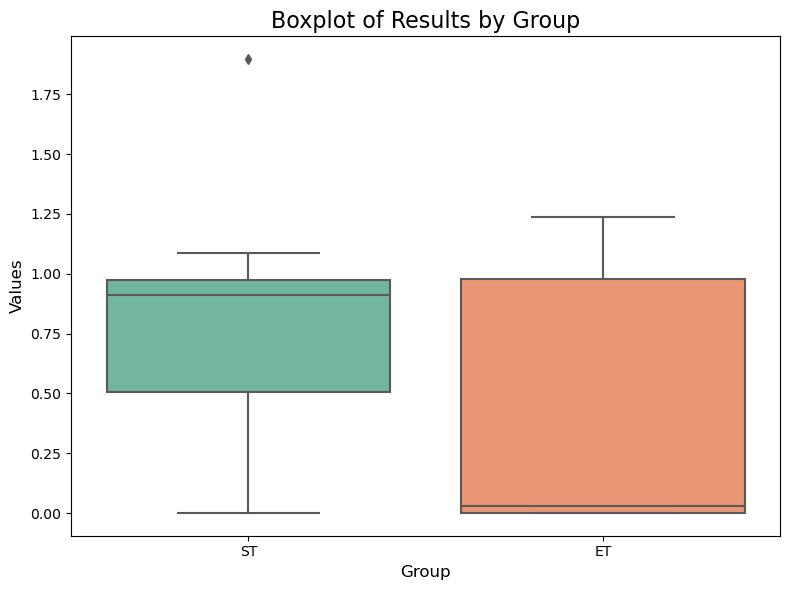

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = dev_lastANDtest

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['dev_percent'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_dev = df.groupby('Group')['dev_percent'].apply(find_outliers)

# Print outliers
print(outliers_dev)

# Optional: visualize outliers in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Group", y='dev_percent', palette="Set2")
plt.title('Boxplot of Results by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
dev_lastANDtest = dev_lastANDtest.reset_index()

In [ ]:
outliers_dev = pd.DataFrame(outliers_dev).reset_index()
outliers_dev_subIds = outliers_dev['subId']

In [ ]:
dev_lastANDtest = dev_lastANDtest[~dev_lastANDtest['subId'].isin(outliers_dev_subIds)]

In [ ]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'last':", shapiro(dev_lastANDtest['last']))
print("Shapiro-Wilk test for 'dev':", shapiro(dev_lastANDtest['dev_percent']))


Shapiro-Wilk test for 'last': ShapiroResult(statistic=0.8711032867431641, pvalue=0.00042905492591671646)
Shapiro-Wilk test for 'dev': ShapiroResult(statistic=0.7787811756134033, pvalue=3.975344952777959e-06)


In [ ]:
dev_lastANDtest = dev_lastANDtest[~dev_lastANDtest['subId'].isin(outliers_dev_subIds)]

In [ ]:

# Convert from wide to long format
dev_lastANDtest_long = dev_lastANDtest.melt(id_vars=["Group", "SubGroup"], 
                  value_vars=["last", "dev"], 
                  var_name="Session", 
                  value_name="CorrectResponses")

In [288]:
dev_lastANDtest_long = dev_lastANDtest_long.dropna()

In [289]:
dev_lastANDtest_long.to_csv('dev_lastANDtest_long3.csv')

In [ ]:
from scipy.stats import wilcoxon

# Wilcoxon test for ET group
stat_ET, p_ET = wilcoxon(dev_lastANDtest[dev_lastANDtest['Group'] == 'ET']['last'], dev_lastANDtest[dev_lastANDtest['Group'] == 'ET']['dev'])

# Wilcoxon test for ST group
stat_ST, p_ST = wilcoxon(dev_lastANDtest[dev_lastANDtest['Group'] == 'ST']['last'], dev_lastANDtest[dev_lastANDtest['Group'] == 'ST']['dev'])

# Compute the z-score manually
N1 = len(dev_lastANDtest[dev_lastANDtest['Group'] == 'ET']['last'])  # Number of paired observations
z1 = (p_ET - (N1 * (N1 + 1) / 4)) / np.sqrt(N1 * (N1 + 1) * (2 * N1 + 1) / 24)

# Compute effect size (r)
r1 = z1 / np.sqrt(N1)

# Compute the z-score manually
N2 = len(dev_lastANDtest[dev_lastANDtest['Group'] == 'ST']['last'])  # Number of paired observations
z2 = (p_ST - (N2 * (N2 + 1) / 4)) / np.sqrt(N2 * (N2 + 1) * (2 * N2 + 1) / 24)

# Compute effect size (r)
r2 = z2 / np.sqrt(N2)

print(f"Wilcoxon test for ET: Statistic = {stat_ET}, p-value = {p_ET}, Z score = {z1:.3f}, Effect Size (r) = {r1:.3f}")
print(f"Wilcoxon test for ST: Statistic = {stat_ST}, p-value = {p_ST}, Z score = {z2:.3f}, Effect Size (r) = {r2:.3f}")


Wilcoxon test for ET: Statistic = 21.0, p-value = 0.000850677490234375, Z score = -3.920, Effect Size (r) = -0.877
Wilcoxon test for ST: Statistic = 11.0, p-value = 0.00041961669921875, Z score = -3.724, Effect Size (r) = -0.878


In [ ]:
from scipy.stats import mannwhitneyu, norm
import numpy as np

def compute_effect_size(U, n1, n2):
    """Compute effect size r using the Z-score method."""
    mean_U = (n1 * n2) / 2  # Expected U
    std_U = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)  # Standard deviation of U
    Z = (U - mean_U) / std_U  # Compute Z-score
    r = abs(Z) / np.sqrt(n1 + n2)  # Effect size r
    return r, Z

# Compare ET vs. ST for "last"
data_et_last = dev_lastANDtest[dev_lastANDtest['Group'] == 'ET']['last']
data_st_last = dev_lastANDtest[dev_lastANDtest['Group'] == 'ST']['last']
n1_last, n2_last = len(data_et_last), len(data_st_last)

stat_last, p_last = mannwhitneyu(data_et_last, data_st_last)
r_last, z_last = compute_effect_size(stat_last, n1_last, n2_last)

# Compare ET vs. ST for "dev"
data_et_dev = dev_lastANDtest[dev_lastANDtest['Group'] == 'ET']['dev_percent']
data_st_dev = dev_lastANDtest[dev_lastANDtest['Group'] == 'ST']['dev_percent']
n1_dev, n2_dev = len(data_et_dev), len(data_st_dev)

stat_dev, p_dev = mannwhitneyu(data_et_dev, data_st_dev)
r_dev, z_dev = compute_effect_size(stat_dev, n1_dev, n2_dev)

# Print results
print(f"Mann-Whitney U test for 'last' between ET and ST: U = {stat_last}, p-value = {p_last}, Z = {z_last:.3f}, effect size r = {r_last:.3f}")
print(f"Mann-Whitney U test for 'dev' between ET and ST: U = {stat_dev}, p-value = {p_dev}, Z = {z_dev:.3f}, effect size r = {r_dev:.3f}")


Mann-Whitney U test for 'last' between ET and ST: U = 171.5, p-value = 0.815036730737503, Z = -0.248, effect size r = 0.040
Mann-Whitney U test for 'dev' between ET and ST: U = 145.0, p-value = 0.3072637070898817, Z = -1.023, effect size r = 0.166


In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

# Function to compute effect size (r) using Z-score
def compute_effect_size_z(U, n1, n2):
    N = n1 + n2
    mean_U = (n1 * n2) / 2
    std_U = np.sqrt((n1 * n2 * (N + 1)) / 12)
    
    # Compute Z-score
    Z = (U - mean_U) / std_U
    r = Z / np.sqrt(N)  # Effect size
    return r

# Store U-values, p-values, and effect sizes
u_values = []
p_values = []
effect_sizes = []

# Pairwise subgroup comparisons
comparisons = [
    ('ET_Left', 'ET_Right'),
    ('ST_Left', 'ST_Right'),
    ('ET_Left', 'ST_Left'),
    ('ET_Right', 'ST_Right')
]

for group1, group2 in comparisons:
    group1_data = dev_lastANDtest[dev_lastANDtest['SubGroup'] == group1]['dev_percent']
    group2_data = dev_lastANDtest[dev_lastANDtest['SubGroup'] == group2]['dev_percent']
    
    n1, n2 = len(group1_data), len(group2_data)
    
    u_stat, p_val = mannwhitneyu(group1_data, group2_data)
    
    # Compute effect size (r) using Z-score method
    r = compute_effect_size_z(u_stat, n1, n2)

    # Store values
    u_values.append(u_stat)
    p_values.append(p_val)
    effect_sizes.append(r)

# Apply correction (Bonferroni or FDR)
corrected_p_fdr = multipletests(p_values, method='fdr_bh')[1]  # Less strict

# Print results
for i, (group1, group2) in enumerate(comparisons):
    print(f"Comparison: {group1} vs. {group2}")
    print(f"  U-value = {u_values[i]:.2f}, p-value = {p_values[i]:.6f}, FDR-corrected p = {corrected_p_fdr[i]:.6f}")
    print(f"  Effect size (r) = {effect_sizes[i]:.3f} (Small: 0.1, Medium: 0.3, Large: 0.5)\n")


Comparison: ET_Left vs. ET_Right
  U-value = 34.50, p-value = 0.255059, FDR-corrected p = 0.510119
  Effect size (r) = -0.255 (Small: 0.1, Medium: 0.3, Large: 0.5)

Comparison: ST_Left vs. ST_Right
  U-value = 38.00, p-value = 1.000000, FDR-corrected p = 1.000000
  Effect size (r) = -0.011 (Small: 0.1, Medium: 0.3, Large: 0.5)

Comparison: ET_Left vs. ST_Left
  U-value = 20.00, p-value = 0.099499, FDR-corrected p = 0.397995
  Effect size (r) = -0.395 (Small: 0.1, Medium: 0.3, Large: 0.5)

Comparison: ET_Right vs. ST_Right
  U-value = 51.50, p-value = 0.908056, FDR-corrected p = 1.000000
  Effect size (r) = 0.034 (Small: 0.1, Medium: 0.3, Large: 0.5)



### Create plot for DEV results

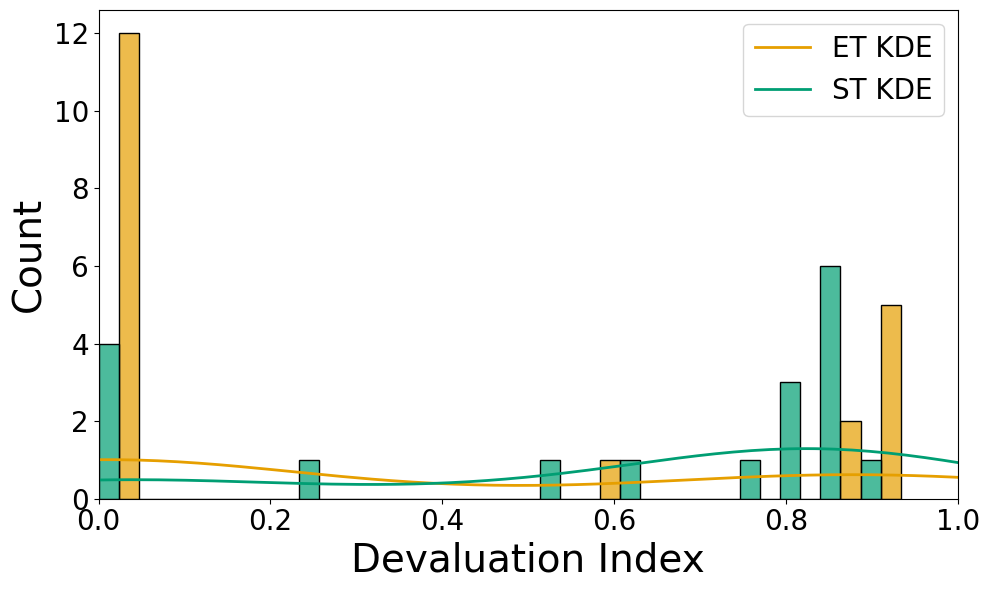

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = dev_lastANDtest

# Define the palette
palette = {"ET": "#E69F00", "ST": "#009E73"}

# Set figure size
plt.figure(figsize=(10, 6))

# Define bins (same for both groups)
num_bins = 20  # Adjust as needed
bin_min = df["dev"].min()
bin_max = df["dev"].max()
bins = np.linspace(bin_min, bin_max, num_bins + 1)  # Ensure equal bin widths

# Create histogram with dodged bars (bars next to each other)
sns.histplot(
    data=df,
    x="dev",
    hue="Group",
    bins=bins,
    multiple="dodge",  # Ensures bars are next to each other
    palette=palette,
    alpha=0.7,  # Transparency to make it clearer
    legend=True
)

# Overlay KDE plots
for group, color in palette.items():
    sns.kdeplot(
        data=df[df["Group"] == group],
        x="dev",
        color=color,
        linewidth=2,
        label=f"{group} KDE"
    )

# Labels and title
plt.xlabel("Devaluation Index", fontsize=28)
plt.ylabel("Count", fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(0,1)
# Ensure the legend is visible
plt.legend(title="Group")
plt.legend(fontsize=20)

# Save and show
plt.tight_layout()
plt.savefig("dev_test_histogram_kde_dodged_pilot3.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
et_per = (etDevResults[0]/et_last_devResults[0]).dropna()
et_per = et_per.reset_index()
et_per["Group"] = "ET"
st_per = (stDevResults[0]/st_last_devResults[0]).dropna()
st_per = st_per.reset_index()
st_per["Group"] = "ST"

In [ ]:
ET_Left = (dev13['dev'])/(last_dev13['last'])
ET_Left = ET_Left.reset_index()
ET_Left["Group"] = "ET_Left"
ST_Left = (dev11['dev']/last_dev11['last'])
ST_Left = ST_Left.reset_index()
ST_Left["Group"] = "ST_Left"
ET_Right = (dev14['dev']/last_dev14['last'])
ET_Right = ET_Right.reset_index()
ET_Right["Group"] = "ET_Right"
ST_Right = (dev12['dev']/last_dev12['last'])
ST_Right = ST_Right.reset_index()
ST_Right["Group"] = "ST_Right"
split = pd.DataFrame([0])
split['subId'] = [1]
split["SubGroup"] = 'Split'


In [ ]:
# dev_per_hands = pd.concat([ST_Left, ST_Right,ET_Left, ET_Right])
# dev_per_hands = dev_per_hands.drop(columns=['index']).rename(columns={0:'Percent'})


In [ ]:
split = split.rename(columns={0:'dev'})
split_ET_Left = pd.concat([dev13[['dev','SubGroup']], split])
split_ET_Right = pd.concat([dev14[['dev','SubGroup']], split])
split_ST_Left = pd.concat([dev11[['dev','SubGroup']], split])
split_ST_Right = pd.concat([dev12[['dev','SubGroup']], split])

/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82594/2043449913.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

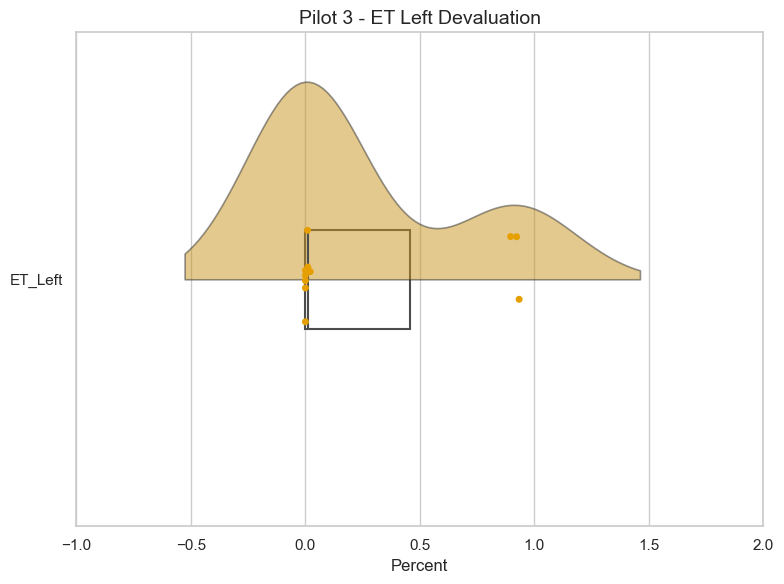

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ET_Left
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ET_Left": "#E69F00", "Split": "#009E73"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ET_Left"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
ax.set_title("Pilot 3 - ET Left Devaluation", fontsize=14)
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ET - Left Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82594/1446661980.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

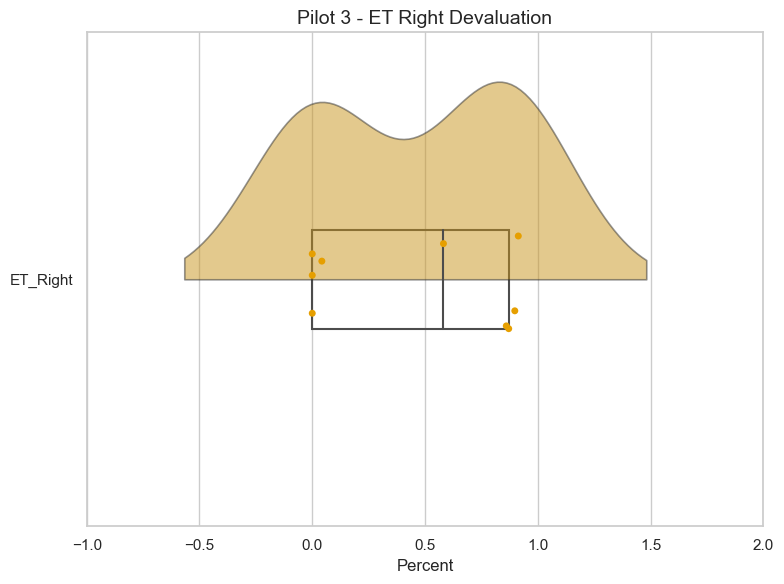

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ET_Right
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ET_Right": "#E69F00", "Split": "#009E73"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ET_Right"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
ax.set_title("Pilot 3 - ET Right Devaluation", fontsize=14)
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ET - Right Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82594/2563899455.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

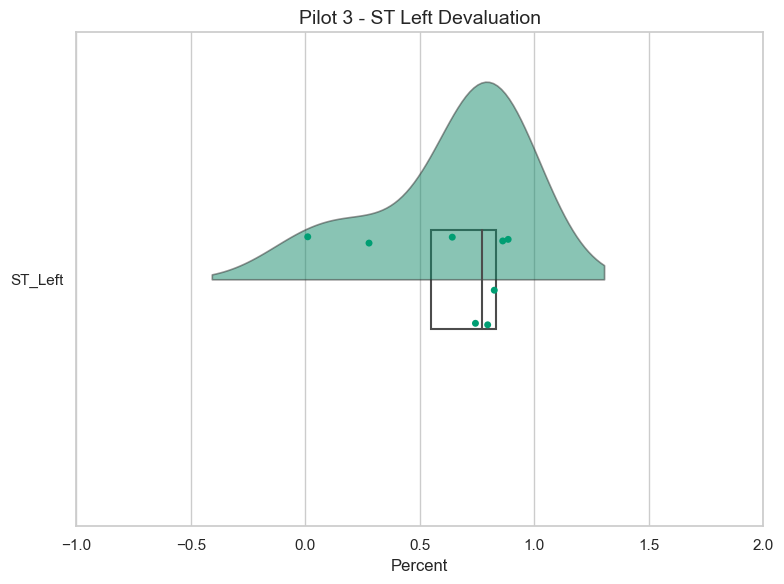

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ST_Left
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ST_Left": "#009E73", "Split": "#E69F00"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ST_Left"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
ax.set_title("Pilot 3 - ST Left Devaluation", fontsize=14)
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ST - Left Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82594/2559559715.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

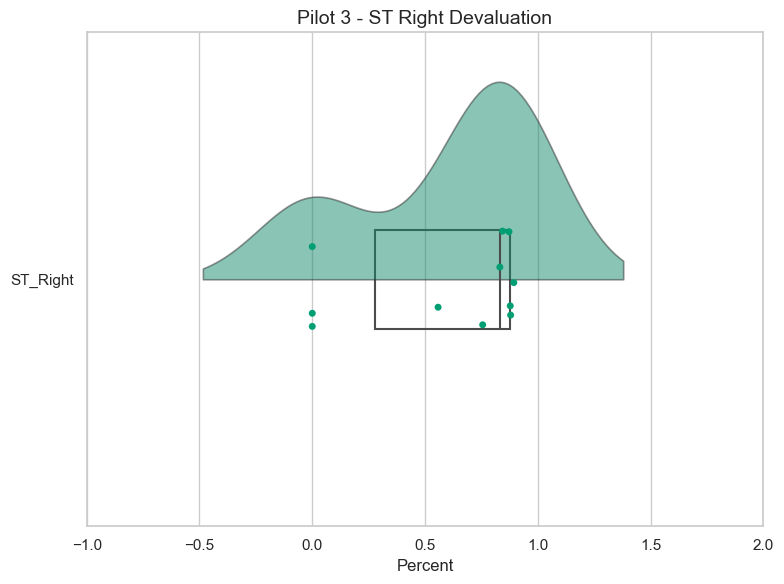

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ST_Right
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ST_Right": "#009E73", "Split": "#E69F00"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ST_Right"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
ax.set_title("Pilot 3 - ST Right Devaluation", fontsize=14)
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ST - Right Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


In [ ]:
stDevResults.rename(columns={0: 'percent'}, inplace=True)
etDevResults.rename(columns={0: 'percent'}, inplace=True)

In [ ]:
stDevResults

,percent
subId,
65c887d0d2c8fb647d0aea85,0.277778
65c887d0d2c8fb647d0aea86,0.795918
65c887d0d2c8fb647d0aea88,0.742574
65c887d0d2c8fb647d0aea8a,0.861702
65c887d0d2c8fb647d0aea8b,0.885417
65c887d0d2c8fb647d0aea8c,0.824742
65c887d0d2c8fb647d0aea8e,0.010101
65c8928cd2c8fb647d0aea9e,0.641304
65c88845d2c8fb647d0aea92,0.877778


In [ ]:
stDevResults = stDevResults.reset_index()
stDevResults['Group']= 'ST'
etDevResults = etDevResults.reset_index()
etDevResults['Group']= 'ET'
stDevResults.drop('subId', axis=1, inplace=True)
etDevResults.drop('subId', axis=1, inplace=True)

## Buttons & star tests:

In [ ]:
st_count_Results = pd.DataFrame(pd.concat([results_additional[11], results_additional[12]], axis=0)).rename(columns={0:'howManyStars'})
et_count_Results = pd.DataFrame(pd.concat([results_additional[13], results_additional[14]], axis=0)).rename(columns={0:'howManyStars'})
choices11 = pd.DataFrame(results_main[11].allStars.groupby('subId').sum())
choices12 = pd.DataFrame(results_main[12].allStars.groupby('subId').sum())
choices13 = pd.DataFrame(results_main[13].allStars.groupby('subId').sum())
choices14 = pd.DataFrame(results_main[14].allStars.groupby('subId').sum())
st_choice_Results = pd.concat([choices11, choices12], axis=0)
et_choice_Results = pd.concat([choices13, choices14], axis=0)


In [ ]:
st_accuracyCount_star = pd.DataFrame(1-(abs(st_choice_Results['allStars']-st_count_Results['howManyStars'])/st_choice_Results['allStars']))
st_accuracyCount_star['Group'] = 'ST'
et_accuracyCount_star = pd.DataFrame(1-(abs(et_choice_Results['allStars']-et_count_Results['howManyStars'])/et_choice_Results['allStars']))
et_accuracyCount_star['Group'] = 'ET'


In [ ]:
st_accuracyCount_star[0] = st_accuracyCount_star[0].replace(1.0, 1.000000)
et_accuracyCount_star[0] = et_accuracyCount_star[0].replace(1.0, 1.000000)


In [ ]:
accuracyCount_star = pd.concat([st_accuracyCount_star,et_accuracyCount_star]).rename(columns={'index':'subId'})

### Outliers stars

Group  subId                   
ET     65ba0c38d2c8fb647d0ae799    0.000000
       65ba0d2bd2c8fb647d0ae7a7    0.250000
ST     65c887d0d2c8fb647d0aea8e    0.653846
Name: 0, dtype: float64


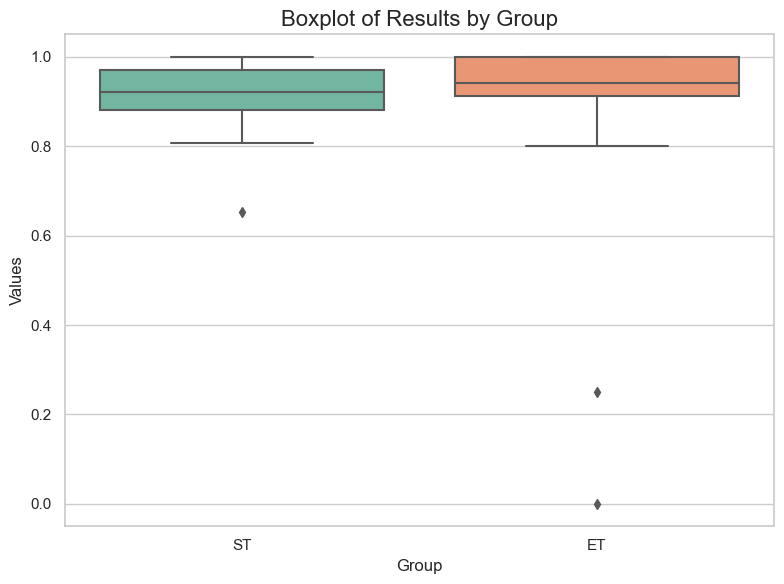

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = accuracyCount_star

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')[0].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_stars_count = df.groupby('Group')[0].apply(find_outliers)

# Print outliers
print(outliers_stars_count)

# Optional: visualize outliers in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Group", y=0, palette="Set2")
plt.title('Boxplot of Results by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
accuracyCount_star = accuracyCount_star.reset_index().rename(columns={'index':'subId'})

In [ ]:
outliers_starts = pd.DataFrame(outliers_stars_count).reset_index().rename(columns={'level_1':'subId'})
outliersStars_subIds = outliers_starts['subId']

In [ ]:
df_stars_cleaned = accuracyCount_star[~accuracyCount_star['subId'].isin(outliersStars_subIds)]

#### Stars stats and plot

In [ ]:
df_stars_cleaned[df_stars_cleaned['Group']=='ET'].describe()

,0
count,18.000000
mean,0.946082
std,0.053752
min,0.800000
25%,0.923077
50%,0.958333
75%,1.000000
max,1.000000


In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_stars_cleaned[df_stars_cleaned['Group'] == 'ST'][0]))
print("Shapiro-Wilk test for 'ET':", shapiro(df_stars_cleaned[df_stars_cleaned['Group'] == 'ET'][0]))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9252151846885681, pvalue=0.14131182432174683)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.863440990447998, pvalue=0.013897890225052834)


In [ ]:
# Extract data for the two groups
group_ST = df_stars_cleaned[df_stars_cleaned['Group']=='ST'][0]
group_ET = df_stars_cleaned[df_stars_cleaned['Group']=='ST'][0]

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")



Mann-Whitney U test: U = 180.50, p-value = 1.000000
Effect size (r) = 0.000


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82594/3738504925.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


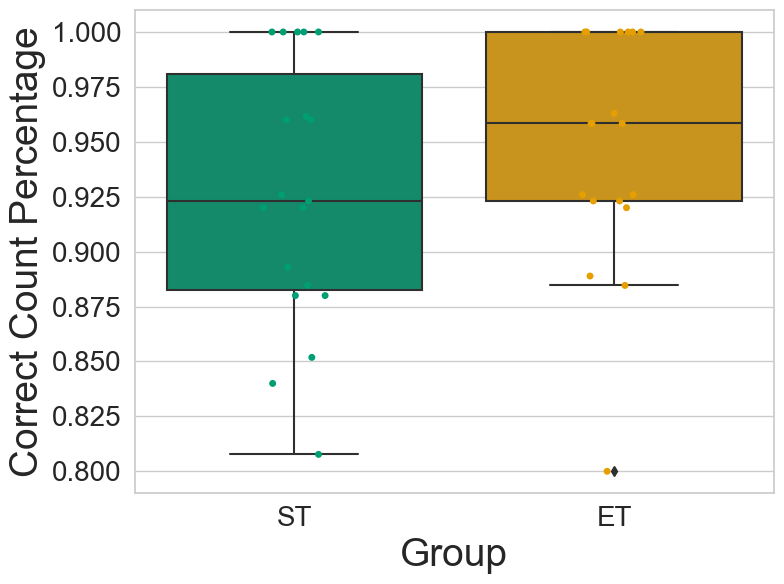

In [ ]:

# Assuming your DataFrame is stored as 'df'
df = df_stars_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y=0, palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y=0, jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
# plt.title('Automaticity test - Pilot 3', fontsize=16)
plt.xlabel('Group', fontsize=28)
plt.ylabel('Correct Count Percentage', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Show the plot
plt.tight_layout()
plt.savefig('Automaticity test.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

plt.show()


#### Stars and Buttons presses

In [ ]:
accuracy_press11 = pd.DataFrame([(results_main[11].correctFirstBluePressStar.groupby('subId').sum()+results_main[11].correctFirstRedPressStar.groupby('subId').sum())/(results_main[11].blueChoiceStar.groupby('subId').sum()+\
results_main[11].redChoiceStar.groupby('subId').sum()), (results_main[11].correctFirstBluePressButtons.groupby('subId').sum()+results_main[11].correctFirstRedPressButtons.groupby('subId').sum())/(results_main[11].blueChoiceButtons.groupby('subId').sum()+\
results_main[11].redChoiceButtons.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Buttons'})
accuracy_press12 = pd.DataFrame([(results_main[12].correctFirstBluePressStar.groupby('subId').sum()+results_main[12].correctFirstRedPressStar.groupby('subId').sum())/(results_main[12].blueChoiceStar.groupby('subId').sum()+\
results_main[12].redChoiceStar.groupby('subId').sum()), (results_main[12].correctFirstBluePressButtons.groupby('subId').sum()+results_main[12].correctFirstRedPressButtons.groupby('subId').sum())/(results_main[12].blueChoiceButtons.groupby('subId').sum()+\
results_main[12].redChoiceButtons.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Buttons'})
accuracy_press13 = pd.DataFrame([(results_main[13].correctFirstBluePressStar.groupby('subId').sum()+results_main[13].correctFirstRedPressStar.groupby('subId').sum())/(results_main[13].blueChoiceStar.groupby('subId').sum()+\
results_main[13].redChoiceStar.groupby('subId').sum()), (results_main[13].correctFirstBluePressButtons.groupby('subId').sum()+results_main[13].correctFirstRedPressButtons.groupby('subId').sum())/(results_main[13].blueChoiceButtons.groupby('subId').sum()+\
results_main[13].redChoiceButtons.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Buttons'})
accuracy_press14 = pd.DataFrame([(results_main[14].correctFirstBluePressStar.groupby('subId').sum()+results_main[14].correctFirstRedPressStar.groupby('subId').sum())/(results_main[14].blueChoiceStar.groupby('subId').sum()+\
results_main[14].redChoiceStar.groupby('subId').sum()), (results_main[14].correctFirstBluePressButtons.groupby('subId').sum()+results_main[14].correctFirstRedPressButtons.groupby('subId').sum())/(results_main[14].blueChoiceButtons.groupby('subId').sum()+\
results_main[14].redChoiceButtons.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Buttons'})
st_accuracyPress_Results = pd.concat([accuracy_press11, accuracy_press12], axis=0)
st_accuracyPress_Results['Group'] = 'ST'
et_accuracyPress_Results = pd.concat([accuracy_press13, accuracy_press14], axis=0)
et_accuracyPress_Results['Group'] = 'ET'

In [ ]:
accuracyPress_Results = pd.concat([st_accuracyPress_Results, et_accuracyPress_Results])


In [ ]:
accuracyPress_Results.describe()

,Stars,Buttons
count,40.000000,40.000000
mean,0.795512,0.774684
std,0.104974,0.100485
min,0.492754,0.521739
25%,0.739130,0.721014
50%,0.811594,0.797101
75%,0.873188,0.855072
max,0.927536,0.913043


In [ ]:
accuracyPress_Results[accuracyPress_Results['Group']=='ST'].describe()

,Stars,Buttons
count,20.000000,20.000000
mean,0.778794,0.759847
std,0.117799,0.097648
min,0.492754,0.521739
25%,0.732630,0.706522
50%,0.811594,0.789855
75%,0.873188,0.840580
max,0.898551,0.884058


In [ ]:
accuracyPress_Results_stars = accuracyPress_Results[['Stars','Group']].reset_index()
accuracyPress_Results_stars = accuracyPress_Results_stars[~accuracyPress_Results_stars['subId'].isin(outliersStars_subIds)].set_index('subId')
accuracyPress_Results_Buttons = accuracyPress_Results[['Buttons','Group']]

#### Buttons presses

In [ ]:
accuracyPress_Results_Buttons[accuracyPress_Results_Buttons['Group']=='ET'].describe()

,Buttons
count,20.000000
mean,0.789522
std,0.103573
min,0.594203
25%,0.732630
50%,0.811594
75%,0.860248
max,0.913043


In [ ]:
# Assuming your DataFrame is stored as 'df'
df = accuracyPress_Results_Buttons

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Buttons'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers = df.groupby('Group')['Buttons'].apply(find_outliers)

# Print outliers
print(outliers)


# plt.figure(figsize=(8, 6))
# sns.boxplot(data=df, x="Group", y='Stars', palette="Set2")
# plt.title('Boxplot of Results by Group', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Values', fontsize=12)
# plt.tight_layout()
# plt.show()


Series([], Name: Buttons, dtype: float64)


In [ ]:
outliers_Buttons_press = pd.DataFrame(outliers).reset_index()
outliersButtonsPress_subIds = outliers_Buttons_press['subId']
accuracyPress_Results_Buttons = accuracyPress_Results_Buttons.reset_index()

In [ ]:
df_ButtonsPress_cleaned = accuracyPress_Results_Buttons[~accuracyPress_Results_Buttons['subId'].isin(outliersButtonsPress_subIds)]

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_ButtonsPress_cleaned[df_ButtonsPress_cleaned['Group']=='ST']['Buttons']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_ButtonsPress_cleaned[df_ButtonsPress_cleaned['Group']=='ET']['Buttons']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9200518131256104, pvalue=0.09931304305791855)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8653867244720459, pvalue=0.009758241474628448)


In [ ]:
# Extract data for the two groups
group_ST = df_ButtonsPress_cleaned[df_ButtonsPress_cleaned['Group']=='ST']['Buttons']
group_ET = df_ButtonsPress_cleaned[df_ButtonsPress_cleaned['Group']=='ET']['Buttons']

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")

Mann-Whitney U test: U = 150.50, p-value = 0.184113
Effect size (r) = 0.210


In [ ]:
df_ButtonsPress_cleaned[df_ButtonsPress_cleaned['Group']=='ST'].describe()

,Buttons
count,20.000000
mean,0.759847
std,0.097648
min,0.521739
25%,0.706522
50%,0.789855
75%,0.840580
max,0.884058


In [ ]:
df_ButtonsPress_cleaned.describe()

,Buttons
count,40.000000
mean,0.774684
std,0.100485
min,0.521739
25%,0.721014
50%,0.797101
75%,0.855072
max,0.913043


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82594/1832848989.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


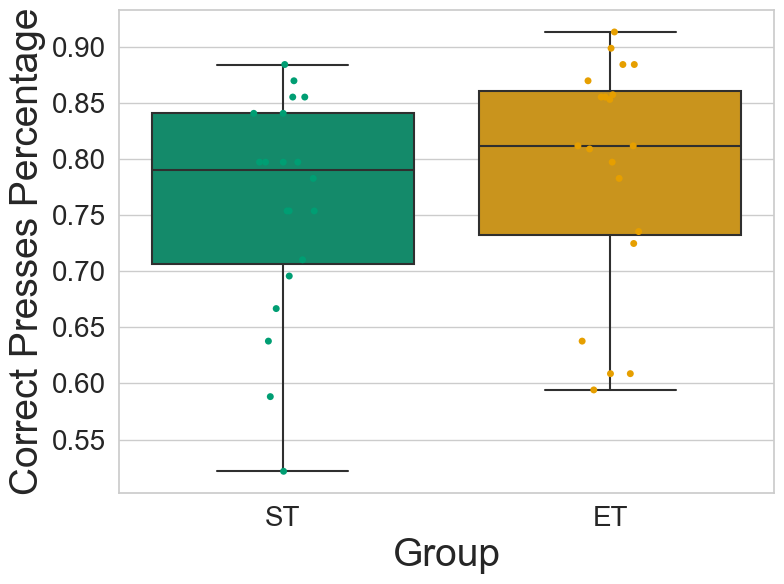

In [ ]:

# Assuming your DataFrame is stored as 'df'
df = df_ButtonsPress_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y='Buttons', palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y='Buttons', jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
# plt.title('Inflexibility  test - Pilot 3', fontsize=28)
plt.xlabel('Group', fontsize=28)
plt.ylabel('Correct Presses Percentage', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Show the plot
plt.tight_layout()
plt.savefig('Inflexibility test.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

plt.show()


#### Stars presses

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = accuracyPress_Results_stars

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Stars'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_stars = df.groupby('Group')['Stars'].apply(find_outliers)

# Print outliers
print(outliers_stars)


# plt.figure(figsize=(8, 6))
# sns.boxplot(data=df, x="Group", y='Stars', palette="Set2")
# plt.title('Boxplot of Results by Group', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Values', fontsize=12)
# plt.tight_layout()
# plt.show()


Group  subId                   
ET     65ba0c38d2c8fb647d0ae795    0.594203
       65ba0d2bd2c8fb647d0ae7a3    0.608696
Name: Stars, dtype: float64


In [ ]:
outliers_stars = pd.DataFrame(outliers_stars).reset_index()

In [ ]:
outliers_Stars_press = pd.DataFrame(outliers_stars).reset_index()
outliersStarsPress_subIds = outliers_stars['subId']
accuracyPress_Results_stars = accuracyPress_Results_stars.reset_index()

In [ ]:
df_StarsPress_cleaned = accuracyPress_Results_stars[~accuracyPress_Results_stars['subId'].isin(outliersStarsPress_subIds)]

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST']['Stars']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ET']['Stars']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.8953368663787842, pvalue=0.04009231552481651)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9710397720336914, pvalue=0.8551591634750366)


In [ ]:
group_ST = df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST']['Stars']
group_ET = df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ET']['Stars']

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")



Mann-Whitney U test: U = 111.50, p-value = 0.184062
Effect size (r) = 0.225


In [ ]:
df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST'].describe()

,Stars
count,19.000000
mean,0.793848
std,0.099312
min,0.565217
25%,0.737212
50%,0.811594
75%,0.876812
max,0.898551


In [ ]:
df_stars_cleaned = df_stars_cleaned.rename(columns={0:'Count'}).set_index('subId')#.drop(columns=['Group'])
accuracyPress_Results_stars = accuracyPress_Results_stars.rename(columns={'Stars':'Presses'}).set_index('subId')
stars3 = pd.concat([df_stars_cleaned, accuracyPress_Results_stars], axis=1).dropna()
stars3['Pilot'] = 3

In [ ]:
stars3.to_csv('stars3.csv')

### Find the last 2 minuts of the game on the first day

In [ ]:
find_alldays_presses_blue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()\
.groupby(['subId', 'createdAt']).max()\

find_alldays_presses_blue13 = find_alldays_presses_blue13[find_alldays_presses_blue13['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_alldays_presses_blue13['correctFirstBluePress'] = find_alldays_presses_blue13['correctFirstBluePress'].apply(filter_list_st)
find_day1_last_presses_blue13= find_alldays_presses_blue13.reset_index()
find_day1_last_presses_blue13 = find_day1_last_presses_blue13.groupby('subId')['correctFirstBluePress'].first()

find_alldays_presses_red13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()\
.groupby(['subId', 'createdAt']).max()\

find_alldays_presses_red13 = find_alldays_presses_red13[find_alldays_presses_red13['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_alldays_presses_red13['correctFirstRedPress'] = find_alldays_presses_red13['correctFirstRedPress'].apply(filter_list_st)
find_day1_last_presses_red13= find_alldays_presses_red13.reset_index()
find_day1_last_presses_red13 = find_day1_last_presses_red13.groupby('subId')['correctFirstRedPress'].first()

find_alldays_presses_blue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()\
.groupby(['subId', 'createdAt']).max()\

find_alldays_presses_blue14 = find_alldays_presses_blue14[find_alldays_presses_blue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_alldays_presses_blue14['correctFirstBluePress'] = find_alldays_presses_blue14['correctFirstBluePress'].apply(filter_list_st)
find_day1_last_presses_blue14= find_alldays_presses_blue14.reset_index()
find_day1_last_presses_blue14 = find_day1_last_presses_blue14.groupby('subId')['correctFirstBluePress'].first()

find_alldays_presses_red14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()\
.groupby(['subId', 'createdAt']).max()\

find_alldays_presses_red14 = find_alldays_presses_red14[find_alldays_presses_red14['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_alldays_presses_red14['correctFirstRedPress'] = find_alldays_presses_red14['correctFirstRedPress'].apply(filter_list_st)
find_day1_last_presses_red14= find_alldays_presses_red14.reset_index()
find_day1_last_presses_red14 = find_day1_last_presses_red14.groupby('subId')['correctFirstRedPress'].first()

find_alldays_choices_blue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).blueChoice.dropna().reset_index()\
.groupby(['subId', 'createdAt']).max()\

find_alldays_choices_blue13 = find_alldays_choices_blue13[find_alldays_choices_blue13['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_alldays_choices_blue13['blueChoice'] = find_alldays_choices_blue13['blueChoice'].apply(filter_list_st)
find_day1_last_choices_blue13= find_alldays_choices_blue13.reset_index()
find_day1_last_choices_blue13 = find_day1_last_choices_blue13.groupby('subId')['blueChoice'].first()

find_alldays_choices_red13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).redChoice.dropna().reset_index()\
.groupby(['subId', 'createdAt']).max()\

find_alldays_choices_red13 = find_alldays_choices_red13[find_alldays_choices_red13['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_alldays_choices_red13['redChoice'] = find_alldays_choices_red13['redChoice'].apply(filter_list_st)
find_day1_last_choices_red13= find_alldays_choices_red13.reset_index()
find_day1_last_choices_red13 = find_day1_last_choices_red13.groupby('subId')['redChoice'].first()

find_alldays_choices_blue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()\
.groupby(['subId', 'createdAt']).max()\

find_alldays_choices_blue14 = find_alldays_choices_blue14[find_alldays_choices_blue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_alldays_choices_blue14['blueChoice'] = find_alldays_choices_blue14['blueChoice'].apply(filter_list_st)
find_day1_last_choices_blue14= find_alldays_choices_blue14.reset_index()
find_day1_last_choices_blue14 = find_day1_last_choices_blue14.groupby('subId')['blueChoice'].first()

find_alldays_choices_red14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).redChoice.dropna().reset_index()\
.groupby(['subId', 'createdAt']).max()\

find_alldays_choices_red14 = find_alldays_choices_red14[find_alldays_choices_red14['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_alldays_choices_red14['redChoice'] = find_alldays_choices_red14['redChoice'].apply(filter_list_st)
find_day1_last_choices_red14= find_alldays_choices_red14.reset_index()
find_day1_last_choices_red14 = find_day1_last_choices_red14.groupby('subId')['redChoice'].first()


In [ ]:
find_alldays_presses_13 = find_alldays_presses_blue13
find_alldays_presses_13['percent'] = ((find_alldays_presses_blue13['correctFirstBluePress']+find_alldays_presses_red13\
['correctFirstRedPress'])/(find_alldays_choices_red13['redChoice']+find_alldays_choices_blue13['blueChoice']))/\
((find_day1_last_presses_blue13+find_day1_last_presses_red13)/(find_day1_last_choices_red13+find_day1_last_choices_blue13))
mask = (find_alldays_presses_13 == 0).all(axis=1)
find_alldays_presses_13 = find_alldays_presses_13[~mask]

find_alldays_presses_14 = find_alldays_presses_blue14
find_alldays_presses_14['percent'] = ((find_alldays_presses_blue14['correctFirstBluePress']+find_alldays_presses_red14\
['correctFirstRedPress'])/(find_alldays_choices_red14['redChoice']+find_alldays_choices_blue14['blueChoice']))/\
((find_day1_last_presses_blue14+find_day1_last_presses_red14)/(find_day1_last_choices_red14+find_day1_last_choices_blue14))
mask = (find_alldays_presses_14 == 0).all(axis=1)
find_alldays_presses_14 = find_alldays_presses_14[~mask]

In [ ]:
find_alldays_presses_13 = find_alldays_presses_13.reset_index()
find_alldays_presses_14 = find_alldays_presses_14.reset_index()

In [ ]:
find_alldays_presses = pd.concat([find_alldays_presses_13,find_alldays_presses_14], axis=0)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Assuming you have your DataFrame 'df' with columns 'subId', 'createdAt', and 'percent'

# # Plot the 'percent' values for each 'subId'
# fig, ax = plt.subplots()

# for subId, find_alldays_presses in find_alldays_presses.groupby('subId'):
#     ax.plot(find_alldays_presses.reset_index()['createdAt'], find_alldays_presses['percent'], label=subId)

# plt.xlabel('CreatedAt')
# plt.ylabel('Percent')
# plt.title('Percent Values for each subId')
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0)
# plt.grid(True)
# plt.xticks(rotation=45)
# plt.show()


In [ ]:
find_alldays_presses_piv = find_alldays_presses.pivot_table(values='percent', index='subId', columns='createdAt')

In [ ]:
statistic, p_value = ttest_ind(find_alldays_presses_piv['2024-02-04'].dropna(), find_alldays_presses_piv['2024-02-13'].dropna())

print(statistic, p_value)

-1.0689865956472298 0.2926067091660333


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82594/1872551977.py:1: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  statistic, p_value = ttest_ind(find_alldays_presses_piv['2024-02-04'].dropna(), find_alldays_presses_piv['2024-02-13'].dropna())


In [ ]:
find_alldays_presses.pivot_table(values='percent', index='subId', columns='createdAt').describe()

createdAt,2024-02-04,2024-02-05,2024-02-06,2024-02-07,2024-02-08,2024-02-09,2024-02-10,2024-02-11,2024-02-12,2024-02-13,2024-02-14
count,18.0,18.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,18.000000,18.000000,10.000000
mean,1.0,1.040408,1.081450,1.072757,1.109082,1.107758,1.077669,1.088323,1.098878,1.067530,1.099103
std,0.0,0.065388,0.192205,0.225850,0.200418,0.229647,0.239752,0.240956,0.232838,0.268015,0.078971
min,1.0,0.927527,0.878059,0.845070,0.906793,0.971831,0.796957,0.756087,0.891566,0.841598,0.991544
25%,1.0,1.002320,0.974196,0.980929,1.010149,1.005712,0.992407,1.008557,1.011796,0.959885,1.056302
50%,1.0,1.038706,1.071580,1.021739,1.046660,1.047283,1.030922,1.057021,1.028852,1.011580,1.100573
75%,1.0,1.080352,1.109307,1.107296,1.142184,1.117394,1.110203,1.078052,1.106238,1.083974,1.114383
max,1.0,1.186536,1.794326,1.928571,1.840932,2.000000,1.976190,2.004053,1.978495,2.050659,1.287313


In [ ]:
find_alldays_presses.pivot_table(values='percent', index='subId', columns='createdAt').describe().T

,count,mean,std,min,25%,50%,75%,max
createdAt,,,,,,,,
2024-02-04,18.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2024-02-05,18.0,1.040408,0.065388,0.927527,1.002320,1.038706,1.080352,1.186536
2024-02-06,19.0,1.081450,0.192205,0.878059,0.974196,1.071580,1.109307,1.794326
2024-02-07,19.0,1.072757,0.225850,0.845070,0.980929,1.021739,1.107296,1.928571
2024-02-08,19.0,1.109082,0.200418,0.906793,1.010149,1.046660,1.142184,1.840932
2024-02-09,19.0,1.107758,0.229647,0.971831,1.005712,1.047283,1.117394,2.000000
2024-02-10,19.0,1.077669,0.239752,0.796957,0.992407,1.030922,1.110203,1.976190
2024-02-11,19.0,1.088323,0.240956,0.756087,1.008557,1.057021,1.078052,2.004053
2024-02-12,18.0,1.098878,0.232838,0.891566,1.011796,1.028852,1.106238,1.978495


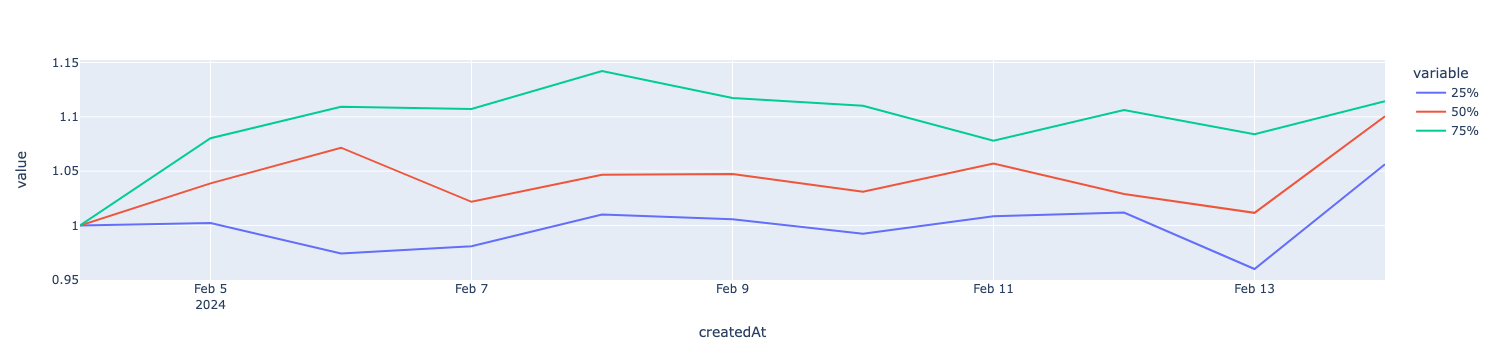

In [ ]:
px.line(find_alldays_presses_piv.describe().T.reset_index(),
        x='createdAt', y=['25%','50%','75%']).show()

In [ ]:
find_alldays_presses_forBox = find_alldays_presses.pivot_table(values='percent', index='subId', columns='createdAt').stack()#.describe().T.reset_index()
find_alldays_presses_forBox = (
    pd.DataFrame(find_alldays_presses_forBox)  # Convert to DataFrame
    .reset_index()  # Reset index
    .rename(columns={0: 'Percent'})  # Rename column
    .sort_values(by='createdAt')  # Sort by createdAt
    .assign(Exp_Day=lambda df: df['createdAt'].rank(method='dense').astype(int)) 
)
find_alldays_presses_forBox

,subId,createdAt,Percent,Exp_Day
0,65ba0c38d2c8fb647d0ae78f,2024-02-04,1.000000,1
185,65bf7bacd2c8fb647d0ae84b,2024-02-04,1.000000,1
175,65ba0d2bd2c8fb647d0ae7a7,2024-02-04,1.000000,1
166,65ba0d2bd2c8fb647d0ae7a6,2024-02-04,1.000000,1
156,65ba0d2bd2c8fb647d0ae7a5,2024-02-04,1.000000,1
...,...,...,...,...
85,65ba0c38d2c8fb647d0ae799,2024-02-14,1.099583,11
10,65ba0c38d2c8fb647d0ae78f,2024-02-14,1.034801,11
96,65ba0c38d2c8fb647d0ae79a,2024-02-14,1.054487,11
42,65ba0c38d2c8fb647d0ae793,2024-02-14,1.287313,11


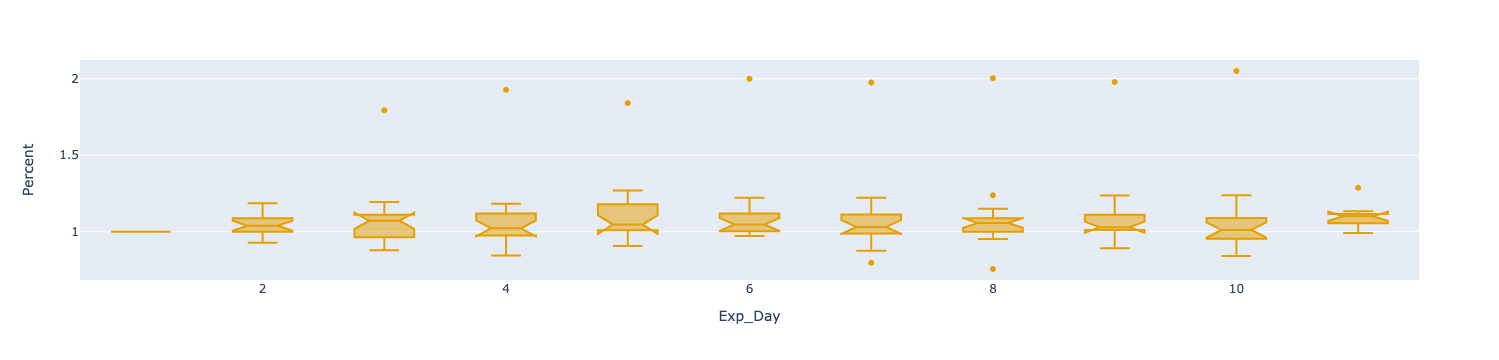

In [ ]:
fig = px.box(find_alldays_presses_forBox, x='Exp_Day', y='Percent', notched=True)
fig.update_traces(quartilemethod="exclusive",marker_color = '#E69F00')
fig.show()

## RT

### RT for stars test

In [ ]:
outliersStars = pd.concat([outliersStars_subIds,outliers_stars])

In [ ]:
RTs = {}

for i in range(11, 15):
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}

    # Filter relevant data
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliersStars)]

    # Iterate over rows for BLUE choices
    for row in dfs[i][['subId', 'correctFirstBluePressStar', 'blueChoiceStar']].dropna().iterrows():
        RT_blue_row = {}
        subId = row[1].subId  # Extract subId

        for ind, correctFirstBluePressStar in enumerate(row[1].correctFirstBluePressStar):
            valid_choices = [x for x in row[1].blueChoiceStar if x < correctFirstBluePressStar]
            RT_blue_row[ind] = correctFirstBluePressStar - valid_choices[-1] if valid_choices else None  # Handle empty list

        if len(RT_blue_row) > 0:
            RT['Blue'][row[0]] = {'RTs': list(RT_blue_row.values()), 'subId': subId}  # Store subId

    # Iterate over rows for RED choices
    for row in dfs[i][['subId', 'correctFirstRedPressStar', 'redChoiceStar']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId  # Extract subId

        for ind, correctFirstRedPressStar in enumerate(row[1].correctFirstRedPressStar):
            valid_choices = [x for x in row[1].redChoiceStar if x < correctFirstRedPressStar]
            RT_red_row[ind] = correctFirstRedPressStar - valid_choices[-1] if valid_choices else None  # Handle empty list

        if len(RT_red_row) > 0:
            RT['Red'][row[0]] = {'RTs': list(RT_red_row.values()), 'subId': subId}  # Store subId

    # Convert to DataFrame
    RTs[i] = pd.DataFrame.from_dict({(key, subkey): values 
                                     for key, subdict in RT.items() 
                                     for subkey, values in subdict.items()}, 
                                     orient='index')

    # Reset index to make 'Color' and 'RowIndex' columns
    RTs[i].reset_index(inplace=True)
    RTs[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)

    # Ensure 'subId' is set as an index or a column
    RTs[i] = RTs[i].set_index('subId')

    # Expand dictionary values into separate columns
    RTs[i] = pd.concat([RTs[i], RTs[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

    # Drop unnecessary nested dictionary column
    RTs[i].drop(columns=[0], inplace=True, errors='ignore')



In [ ]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [ ]:
mean_RTs = {}

for grp, RT in RTs.items():
    # Compute mean RTs while keeping 'subId'
    mean_df = RT.groupby(["subId", "Color"])["RTs"].apply(lambda x: 
        pd.Series([item for sublist in x.dropna() for item in to_list(sublist)]).mean()
    ).unstack()  # Convert 'Color' categories into separate columns

    # Store the result
    mean_RTs[grp] = mean_df.reset_index()  # Ensure 'subId' is a column


In [ ]:
BandRST = pd.concat([mean_RTs[11], mean_RTs[12]]).reset_index()
BandRST["Group"]="ST"
BandRET = pd.concat([mean_RTs[13], mean_RTs[14]]).reset_index()
BandRET["Group"]="ET"
BandR = pd.concat([BandRST,BandRET])
BandR = BandR.drop(columns = "index")
BandR = BandR.rename(columns={0:"MeanRT"})#.drop(columns=['index'])

In [ ]:
BandR = BandR.reset_index().melt(id_vars=['subId', 'Group'], 
                                  value_vars=['Blue', 'Red'], 
                                  var_name='Color', 
                                  value_name='MeanRT')


In [ ]:
# Assuming your DataFrame is stored as 'df'
df = BandR

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['MeanRT'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_stars = df.groupby('Group')['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_RT_stars)

Series([], Name: MeanRT, dtype: float64)


In [ ]:
outliers_RT_Stars = pd.DataFrame(outliers_RT_stars).reset_index()
outliers_RT_Stars_subIds = outliers_RT_Stars['level_1']

In [ ]:
df_RT_Stars_cleaned = BandR[~BandR['subId'].isin(outliers_RT_Stars_subIds)]

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(BandR[BandR['Group']=='ST']['MeanRT'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(BandR[BandR['Group']=='ET']['MeanRT'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9832562804222107, pvalue=0.8074555993080139)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9798638820648193, pvalue=0.684496283531189)


In [ ]:
# Extract data for the two groups
group_ST = BandR[BandR['Group']=='ST']['MeanRT'].dropna()
group_ET = BandR[BandR['Group']=='ET']['MeanRT'].dropna()

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = 1.93, p-value = 0.057661
Cohen's d = 0.431


In [ ]:
df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ST']['MeanRT'].describe()

count     40.000000
mean     790.096993
std       50.206130
min      682.525000
25%      751.986895
50%      795.783531
75%      828.708525
max      905.214286
Name: MeanRT, dtype: float64

In [ ]:
# cohend(BandRST[0].dropna(), BandRET[0].dropna())

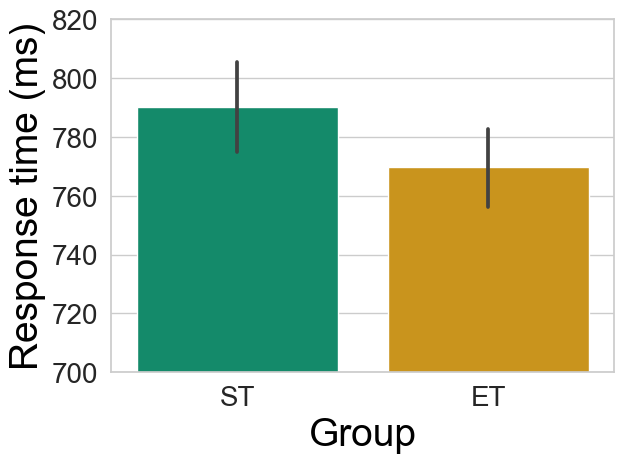

In [ ]:

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Stars_cleaned, x="Group", y="MeanRT", palette=custom_palette)

# Set axis limits
plt.ylim(700, 820)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

# plt.title('Stars response time - Pilot 3', fontsize=16)
plt.xlabel('Group', fontsize=28)
plt.ylabel('Response time (ms)', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
# Save the figure
plt.savefig("response_time_stars.png")

# Show the plot
plt.show()


In [ ]:
df_RT_Stars_cleaned['Pilot'] = 3
df_RT_Stars_cleaned#.to_csv('df_RT_Stars_cleaned3.csv')

,subId,Group,Color,MeanRT,Pilot
0,65c887d0d2c8fb647d0aea85,ST,Blue,706.280000,3
1,65c887d0d2c8fb647d0aea86,ST,Blue,733.863636,3
2,65c887d0d2c8fb647d0aea88,ST,Blue,776.967742,3
3,65c887d0d2c8fb647d0aea89,ST,Blue,740.642857,3
4,65c887d0d2c8fb647d0aea8a,ST,Blue,836.846154,3
...,...,...,...,...,...
75,65ba0d2bd2c8fb647d0ae7a3,ET,Red,690.900000,3
76,65ba0d2bd2c8fb647d0ae7a4,ET,Red,776.212121,3
77,65ba0d2bd2c8fb647d0ae7a5,ET,Red,793.060606,3
78,65ba0d2bd2c8fb647d0ae7a6,ET,Red,772.629630,3


### RT training

In [ ]:
# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list_RTs(lst):
    if len([item for item in lst if isinstance(item, int) and item > 180000])==0:
           return np.nan
    return [item for item in lst if isinstance(item, int) and item > 180000]

In [ ]:
dfs_for_RT_blue = {}
dfs_for_RT_red = {}
dfs_for_RT = {}

for i in range (13, 15):
    dfs_for_RT_blue[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstBluePress', 'blueChoice']].dropna().reset_index()
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i][dfs_for_RT_blue[i]['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_blue[i]['correctFirstBluePress'] = dfs_for_RT_blue[i]['correctFirstBluePress'].apply(filter_list_RTs)
    dfs_for_RT_blue[i]['blueChoice'] = dfs_for_RT_blue[i]['blueChoice'].apply(filter_list_RTs)
    dfs_for_RT_blue[i].sort_values(by='createdAt', ascending=True, inplace=True)
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].groupby('subId').apply(fix_subId)
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].drop(columns=['subId'])

    dfs_for_RT_red[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstRedPress', 'redChoice']].dropna().reset_index()
    dfs_for_RT_red[i] = dfs_for_RT_red[i][dfs_for_RT_red[i]['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_red[i]['correctFirstRedPress'] = dfs_for_RT_red[i]['correctFirstRedPress'].apply(filter_list_RTs)
    dfs_for_RT_red[i]['redChoice'] = dfs_for_RT_red[i]['redChoice'].apply(filter_list_RTs)
    dfs_for_RT_red[i].sort_values(by='createdAt', ascending=True, inplace=True)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].groupby('subId').apply(fix_subId)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].drop(columns=['subId','createdAt'])

    
for i in range (11, 13):    
    dfs_for_RT_blue[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstBluePress', 'blueChoice']].dropna().reset_index()
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i][dfs_for_RT_blue[i]['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_blue[i]['correctFirstBluePress'] = dfs_for_RT_blue[i]['correctFirstBluePress'].apply(filter_list_RTs)
    dfs_for_RT_blue[i]['blueChoice'] = dfs_for_RT_blue[i]['blueChoice'].apply(filter_list_RTs)
    dfs_for_RT_blue[i].sort_values(by=['subId', 'createdAt'])
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].groupby('subId', as_index=True).first()
    
    dfs_for_RT_red[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstRedPress', 'redChoice']].dropna().reset_index()
    dfs_for_RT_red[i] = dfs_for_RT_red[i][dfs_for_RT_red[i]['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_red[i]['correctFirstRedPress'] = dfs_for_RT_red[i]['correctFirstRedPress'].apply(filter_list_RTs)
    dfs_for_RT_red[i]['redChoice'] = dfs_for_RT_red[i]['redChoice'].apply(filter_list_RTs)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].groupby('subId', as_index=True).first()
    dfs_for_RT_red[i] = dfs_for_RT_red[i].drop(columns=['createdAt'])

for i in range (11, 15):    
    dfs_for_RT[i] = pd.concat([dfs_for_RT_blue[i], dfs_for_RT_red[i]], axis=1).reset_index().rename(columns={'index': 'subId'})

In [ ]:
for i in range(12, 14):
# Remove the first element from each list in the 'correctFirstBluePress' column for all rows
    dfs_for_RT[13]['correctFirstBluePress'] = dfs_for_RT[13]['correctFirstBluePress'].apply(
        lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    )
    # dfs_for_RT[12]['correctFirstRedPress'] = dfs_for_RT[12]['correctFirstRedPress'].apply(
    #     lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    # )
    # dfs_for_RT[14]['correctFirstRedPress'] = dfs_for_RT[14]['correctFirstRedPress'].apply(
    #     lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    # )

In [ ]:
RTs_general = {}
Ts_general = {}
for i in range(11, 15):
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}
    RT_df = dfs_for_RT[i]
    for row in RT_df[['subId', 'createdAt', 'correctFirstBluePress', 'blueChoice']].dropna().iterrows():
        RT_blue_row = {}
        subId = row[1].subId
        createdAt = row[1].createdAt
        
        for ind, correctFirstBluePress in enumerate(sorted(row[1].correctFirstBluePress)):
            row[1].blueChoice = sorted(row[1].blueChoice) 
            RT_blue_row[ind] = correctFirstBluePress - [x for x in row[1].blueChoice if x < correctFirstBluePress][-1]
        
        if len(RT_blue_row) > 0:
            RT['Blue'][row[0]] = {'RTs': list(RT_blue_row.values()), 'subId': subId, 'createdAt': createdAt}

    for row in RT_df[['subId', 'createdAt', 'correctFirstRedPress', 'redChoice']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId
        createdAt = row[1].createdAt

        for ind, correctFirstRedPress in enumerate(sorted(row[1].correctFirstRedPress)):
            RT_red_row[ind] = correctFirstRedPress - [x for x in row[1].redChoice if x < correctFirstRedPress][-1]
        
        if len(RT_red_row) > 0:
            RT['Red'][row[0]] = {'RTs': list(RT_red_row.values()), 'subId': subId, 'createdAt': createdAt}

        # Convert nested dictionary to DataFrame
        RTs_general[i] = pd.DataFrame.from_dict({(key, subkey): values 
                                                 for key, subdict in RT.items() 
                                                 for subkey, values in subdict.items()}, 
                                                 orient='index')

        # Reset index so 'Color' and 'RowIndex' become columns
        RTs_general[i].reset_index(inplace=True)
        RTs_general[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)
        RTs_general[i] = RTs_general[i].set_index('subId')
        # Expand dictionary values (RTs, subId, createdAt) into separate columns
        RTs_general[i] = pd.concat([RTs_general[i], RTs_general[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

        # Drop the original column that stored the dictionaries (it has been expanded)
        RTs_general[i].drop(columns=[0], inplace=True, errors='ignore')  # 'ignore' avoids errors if the column doesn't exist

In [ ]:
df_reset = {}
df_means = {}

for i in range (11,15):
    # Reset index to ensure 'subId' and 'Color' are columns
    df_reset[i] = RTs_general[i].reset_index().dropna()

    # Compute the mean RTs for each combination of 'subId' and 'Color'
    df_means[i] = df_reset[i].groupby(['subId', 'Color'])['RTs'].apply(lambda x: np.mean(x.values[0]) if isinstance(x.values[0], list) else np.nan).unstack()

    # Rename columns for clarity
    df_means[i].columns = ['MeanRT_Blue', 'MeanRT_Red']
    # df_means[i]['Mean_All'] = df_means[i][['MeanRT_Blue', 'MeanRT_Red']].mean(axis=1)
    if i in range (11,13):
        df_means[i]['Group'] = 'ST'
    else:
        df_means[i]['Group'] = 'ET'

In [ ]:
df_means = pd.concat([df_means[11],df_means[12],df_means[13],df_means[14]])

In [ ]:
# Reset index to make 'subId' a column before melting
RT_means_training = df_means.reset_index().melt(id_vars=['subId', 'Group'], 
                                  value_vars=['MeanRT_Blue', 'MeanRT_Red'], 
                                  var_name='Color', 
                                  value_name='MeanRT')


In [ ]:
# Assuming your DataFrame is stored as 'df'
df = RT_means_training

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['MeanRT'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_training = df.groupby('Group')['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_RT_training)

Group    
ET     61    891.058824
Name: MeanRT, dtype: float64


In [ ]:
outliers_RT_training

Group    
ET     61    891.058824
Name: MeanRT, dtype: float64

In [ ]:
outliers_RT_training = pd.DataFrame(outliers_RT_training).reset_index()
outliers_RT_training_subIds = outliers_RT_training['level_1']
RT_means_training = RT_means_training.reset_index()

In [ ]:
df_RT_training_cleaned = RT_means_training[~RT_means_training['index'].isin(outliers_RT_training_subIds)]

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(RT_means_training[RT_means_training['Group']=='ST']['MeanRT'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(RT_means_training[RT_means_training['Group']=='ET']['MeanRT'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9713342189788818, pvalue=0.39629295468330383)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9811976552009583, pvalue=0.7338624000549316)


In [ ]:
df_RT_Stars_cleaned

,subId,Group,Color,MeanRT,Pilot
0,65c887d0d2c8fb647d0aea85,ST,Blue,706.280000,3
1,65c887d0d2c8fb647d0aea86,ST,Blue,733.863636,3
2,65c887d0d2c8fb647d0aea88,ST,Blue,776.967742,3
3,65c887d0d2c8fb647d0aea89,ST,Blue,740.642857,3
4,65c887d0d2c8fb647d0aea8a,ST,Blue,836.846154,3
...,...,...,...,...,...
75,65ba0d2bd2c8fb647d0ae7a3,ET,Red,690.900000,3
76,65ba0d2bd2c8fb647d0ae7a4,ET,Red,776.212121,3
77,65ba0d2bd2c8fb647d0ae7a5,ET,Red,793.060606,3
78,65ba0d2bd2c8fb647d0ae7a6,ET,Red,772.629630,3


In [ ]:
df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ET']['MeanRT'].describe()

count     40.000000
mean     769.773276
std       43.933897
min      677.666667
25%      735.758929
50%      774.806061
75%      798.479392
max      853.178571
Name: MeanRT, dtype: float64

In [ ]:
RT_means_training['Pilot'] = 3
df_RT_Stars_cleaned['Pilot'] = 3
df_RT_Stars_cleaned.to_csv('df_RT_Stars_cleaned3.csv')

In [ ]:
df_RT_Stars_cleaned = df_RT_Stars_cleaned.rename(columns={'Response time':'MeanRT'})
df_RT_Stars_cleaned['step'] = 'Stars'
RT_means_training['step'] = 'Training'
#,RT_means_training['MeanRT']

In [ ]:
rt_stars_training = pd.concat([df_RT_Stars_cleaned,RT_means_training])

In [ ]:
rt_stars_training

,subId,Group,Color,MeanRT,Pilot,step,index
0,65c887d0d2c8fb647d0aea85,ST,Blue,706.280000,3,Stars,NaN
1,65c887d0d2c8fb647d0aea86,ST,Blue,733.863636,3,Stars,NaN
2,65c887d0d2c8fb647d0aea88,ST,Blue,776.967742,3,Stars,NaN
3,65c887d0d2c8fb647d0aea89,ST,Blue,740.642857,3,Stars,NaN
4,65c887d0d2c8fb647d0aea8a,ST,Blue,836.846154,3,Stars,NaN
...,...,...,...,...,...,...,...
75,65ba0d2bd2c8fb647d0ae7a3,ET,MeanRT_Red,664.634146,3,Training,75.0
76,65ba0d2bd2c8fb647d0ae7a4,ET,MeanRT_Red,754.900000,3,Training,76.0
77,65ba0d2bd2c8fb647d0ae7a5,ET,MeanRT_Red,786.777778,3,Training,77.0
78,65ba0d2bd2c8fb647d0ae7a6,ET,MeanRT_Red,717.659091,3,Training,78.0


In [ ]:
# rt_stars_training = rt_stars_training.drop(columns=['index','Pilot','subId','Color'])
rt_stars_training['Pilot'] = 3
rt_stars_training.to_csv('rt_stars_training3.csv')

### RT for buttons

In [ ]:
RTs_Buttons = {}

for i in range(11, 15):
    RT = {'Blue': {}, 'Red': {}}
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliersButtonsPress_subIds)]
    for row in dfs[i][['correctFirstBluePressButtons', 'blueChoiceButtons']].dropna().iterrows():
        # print(row[1])
        # print()
        RT_blue_row = {}
        counter = 0
        for correctFirstBluePressButtons in row[1].correctFirstBluePressButtons:
            choices_before_press = [x for x in row[1].blueChoiceButtons if x<correctFirstBluePressButtons]
            # print(correctFirstRedPressButtons, choices_before_press)
            if len(choices_before_press)>0:
                RT_blue_row[counter] = correctFirstBluePressButtons - choices_before_press[-1]
                counter += 1 
        # break         
        if len(RT_blue_row)>0:
            RT['Blue'][row[0]] = list(RT_blue_row.values())
    
    for row in dfs[i][['correctFirstRedPressButtons', 'redChoiceButtons']].dropna().iterrows():
        RT_red_row = {}
        counter = 0
        for correctFirstRedPressButtons in row[1].correctFirstRedPressButtons:
            choices_before_press = [x for x in row[1].redChoiceButtons if x<correctFirstRedPressButtons]
            if len(choices_before_press)>0:
                RT_red_row[counter] = correctFirstRedPressButtons - choices_before_press[-1]
                counter += 1 
        if len(RT_red_row)>0:
            RT['Red'][row[0]] = list(RT_red_row.values())
    
    RTs_Buttons[i] = pd.DataFrame(RT)


In [ ]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [ ]:
mean_RTs_buttons = {grp: pd.DataFrame({'Blue': RT.Blue.apply(lambda x: pd.Series({i: y for i,y in enumerate(to_list(x))})).T.mean(),
                  'Red': RT.Red.apply(lambda x: pd.Series({i: y for i,y in enumerate(to_list(x))})).T.mean()})
            for grp, RT in RTs_Buttons.items()}

In [ ]:
BandRST_buttons = pd.concat([mean_RTs_buttons[11]["Blue"], mean_RTs_buttons[11]["Red"], mean_RTs_buttons[12]["Blue"], mean_RTs_buttons[12]["Red"]]).reset_index()
BandRST_buttons["Group"]="ST"
BandRET_buttons = pd.concat([mean_RTs_buttons[13]["Blue"], mean_RTs_buttons[13]["Red"], mean_RTs_buttons[14]["Blue"], mean_RTs_buttons[14]["Red"]]).reset_index()
BandRET_buttons["Group"]="ET"
BandR_buttons = pd.concat([BandRST_buttons,BandRET_buttons])
BandR_buttons = BandR_buttons.drop(columns = "index")
BandR_buttons= BandR_buttons.rename(columns={0:"Response time"})

In [ ]:
BandR_buttons = BandR_buttons.reset_index()

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = BandR_buttons

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_buttons = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_stars)

Series([], Name: MeanRT, dtype: float64)


In [ ]:
outliers_RT_buttons

Group    
ET     74    857.714286
ST     4     681.900000
       6     680.777778
Name: Response time, dtype: float64

In [ ]:
outliers_RT_Buttons = pd.DataFrame(outliers_RT_buttons).reset_index()
outliers_RT_Buttons_subIds = outliers_RT_Buttons['level_1']

In [ ]:
df_RT_Buttons_cleaned = BandR_buttons[~BandR_buttons['index'].isin(outliers_RT_Buttons_subIds)]

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_Buttons_cleaned[df_RT_Buttons_cleaned['Group']=='ST']['Response time']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_Buttons_cleaned[df_RT_Buttons_cleaned['Group']=='ET']['Response time']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9789677262306213, pvalue=0.6808552145957947)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9864400029182434, pvalue=0.9178776741027832)


In [ ]:
group_ST = df_RT_Buttons_cleaned[df_RT_Buttons_cleaned['Group']=='ST']['Response time']
group_ET = df_RT_Buttons_cleaned[df_RT_Buttons_cleaned['Group']=='ET']['Response time']
# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = 2.16, p-value = 0.033792
Cohen's d = 0.496


In [ ]:
df_RT_Buttons_cleaned.describe()#[df_RT_Buttons_cleaned['Group']=='ET'].describe()

,index,Response time
count,76.000000,76.000000
mean,20.263158,768.801136
std,11.413873,40.143129
min,0.000000,671.000000
25%,11.000000,739.392787
50%,20.500000,769.301515
75%,30.000000,797.129091
max,39.000000,857.714286


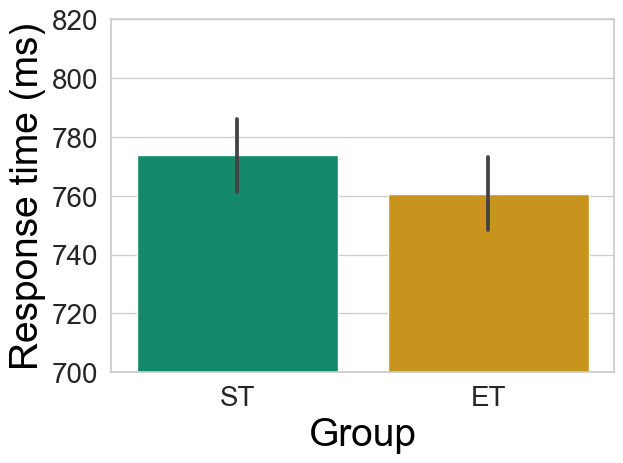

In [ ]:

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=BandR_buttons, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(700, 820)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

# plt.title('Buttons test - Response time', fontsize=16)
plt.xlabel('Group', fontsize=28)
plt.ylabel('Response time (ms)', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
# Save the figure
plt.savefig("response_time_buttons.png")

# Show the plot
plt.show()



### RT comperison:

In [ ]:
RTs_general = {}
for i in range(11,15):
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    for row in dfs[i][['correctFirstBluePress','blueChoice']].dropna().iterrows():
        RT_blue_row = {}
        for ind, correctFirstBluePress in enumerate(row[1].correctFirstBluePress):
            RT_blue_row[ind] = correctFirstBluePress - [x for x in row[1].blueChoice if x<correctFirstBluePress][-1]
        if len(RT_blue_row)>0:
            RT['Blue'][row[0]] = list(RT_blue_row.values())
    for row in dfs[i][['correctFirstRedPress','redChoice']].dropna().iterrows():
        RT_red_row = {}
        for ind, correctFirstRedPress in enumerate(row[1].correctFirstRedPress):
            RT_red_row[ind] = correctFirstRedPress - [x for x in row[1].redChoice if x<correctFirstRedPress][-1]
        if len(RT_red_row)>0:
            RT['Red'][row[0]] = list(RT_red_row.values())
    RTs_general[i] = pd.DataFrame(RT)

In [ ]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [ ]:
mean_RTs_general = {grp: pd.DataFrame({'Blue': RT.Blue.apply(lambda x: pd.Series({i: y for i,y in enumerate(to_list(x))})).T.mean(),
                  'Red': RT.Red.apply(lambda x: pd.Series({i: y for i,y in enumerate(to_list(x))})).T.mean()})
            for grp, RT in RTs_general.items()}

In [ ]:
BandRST_general = pd.concat([mean_RTs_general[11]["Blue"], mean_RTs_general[11]["Red"], mean_RTs_general[12]["Blue"], mean_RTs_general[12]["Red"]]).reset_index()
BandRST_general["Group"]="ST"
BandRET_general = pd.concat([mean_RTs_general[13]["Blue"], mean_RTs_general[13]["Red"], mean_RTs_general[14]["Blue"], mean_RTs_general[14]["Red"]]).reset_index()
BandRET_general["Group"]="ET"
BandR_general = pd.concat([BandRST_general,BandRET_general])
BandR_general = BandR_general.drop(columns = "index")
BandR_general = BandR_general.rename(columns={0:"Response time"})

In [ ]:
BandR_general[BandR_general["Group"]=="ST"]

,Response time,Group
0,853.462500,ST
1,698.195652,ST
2,748.769231,ST
3,675.040816,ST
4,655.451613,ST
...,...,...
115,650.750000,ST
116,873.000000,ST
117,766.555556,ST
118,711.875000,ST


In [ ]:
statistic, p_value = ttest_ind(BandRST_general[0].dropna(), BandRET_general[0].dropna())
print(statistic, p_value)

-0.39328856774261944 0.6942484326439781


### RT for devaluation test

In [ ]:
RTs_Dev = {}

for i in range(11, 15):
    RT = {'Blue': {}, 'Red': {}}
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    # dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliers_Dev['subId'])]
    for row in dfs[i][['correctFirstBluePressDevtest', 'blueChoiceDev']].dropna().iterrows():
        # print(row[1])
        # print()
        RT_blue_row = {}
        counter = 0
        for correctFirstBluePressDev in row[1].correctFirstBluePressDevtest:
            choices_before_press = [x for x in row[1].blueChoiceDev if x<correctFirstBluePressDev]
            # print(correctFirstRedPressButtons, choices_before_press)
            if len(choices_before_press)>0:
                RT_blue_row[counter] = correctFirstBluePressDev - choices_before_press[-1]
                counter += 1 
        # break         
        if len(RT_blue_row)>0:
            RT['Blue'][row[0]] = list(RT_blue_row.values())
    
    for row in dfs[i][['correctFirstRedPressDevtest', 'redChoiceDev']].dropna().iterrows():
        RT_red_row = {}
        counter = 0
        for correctFirstRedPressDev in row[1].correctFirstRedPressDevtest:
            choices_before_press = [x for x in row[1].redChoiceDev if x<correctFirstRedPressDev]
            if len(choices_before_press)>0:
                RT_red_row[counter] = correctFirstRedPressDev - choices_before_press[-1]
                counter += 1 
        if len(RT_red_row)>0:
            RT['Red'][row[0]] = list(RT_red_row.values())
    
    RTs_Dev[i] = pd.DataFrame(RT)


In [ ]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [ ]:
mean_RTs_Dev = {grp: pd.DataFrame({'Blue': RT.Blue.apply(lambda x: pd.Series({i: y for i,y in enumerate(to_list(x))})).T.mean(),
                  'Red': RT.Red.apply(lambda x: pd.Series({i: y for i,y in enumerate(to_list(x))})).T.mean()})
            for grp, RT in RTs_Dev.items()}

In [ ]:
BandRST_Dev = pd.concat([mean_RTs_Dev[11]["Red"], mean_RTs_Dev[12]["Blue"]]).reset_index()
BandRST_Dev['Condition'] = 'Dev'
BandRST_Dev["Group"]="ST"
BandRST_NonDev = pd.concat([mean_RTs_Dev[11]["Blue"], mean_RTs_Dev[12]["Red"]]).reset_index()
BandRST_NonDev['Condition'] = 'nonDev'
BandRST_NonDev["Group"]="ST"
BandRET_Dev = pd.concat([mean_RTs_Dev[13]["Red"], mean_RTs_Dev[14]["Blue"]]).reset_index()
BandRET_Dev['Condition'] = 'Dev'
BandRET_Dev["Group"]="ET"
BandRET_NonDev = pd.concat([mean_RTs_Dev[13]["Blue"], mean_RTs_Dev[14]["Red"]]).reset_index()
BandRET_NonDev['Condition'] = 'nonDev'
BandRET_NonDev["Group"]="ET"
BandR_Dev = pd.concat([BandRST_Dev,BandRET_Dev])
BandR_Dev = BandR_Dev.drop(columns = "index").dropna()
BandR_Dev= BandR_Dev.rename(columns={0:"Response time"})
BandR_NonDev = pd.concat([BandRST_NonDev,BandRET_NonDev])
BandR_NonDev = BandR_NonDev.drop(columns = "index").dropna()
BandR_NonDev= BandR_NonDev.rename(columns={0:"Response time"})

In [ ]:
BandRET_Dev = BandRET_Dev.set_index('index').rename(columns={0:'RT'})
BandRET_NonDev = BandRET_NonDev.set_index('index').rename(columns={0:'RT'})
BandRST_Dev = BandRST_Dev.set_index('index').rename(columns={0:'RT'})
BandRST_NonDev = BandRST_NonDev.set_index('index').rename(columns={0:'RT'})


In [ ]:
BandRST_Dev = BandRST_Dev.reset_index()
BandRST_NonDev = BandRST_NonDev.reset_index()
BandRST_Dev_indexNan = BandRST_Dev[BandRST_Dev['RT'].isna()]['index']
BandRET_Dev = BandRET_Dev.reset_index()
BandRET_NonDev = BandRET_NonDev.reset_index()
BandRET_Dev_indexNan = BandRET_Dev[BandRET_Dev['RT'].isna()]['index']

In [ ]:
BandRST_NonDev = BandRST_NonDev[~BandRST_NonDev['index'].isin(BandRST_Dev_indexNan)]
BandRET_NonDev = BandRET_NonDev[~BandRET_NonDev['index'].isin(BandRET_Dev_indexNan)]

#### Mixed ANOVA

In [ ]:
devRT_ET = pd.concat([BandRET_Dev,BandRET_NonDev]).dropna()
devRT_ST = pd.concat([BandRST_Dev,BandRST_NonDev]).dropna()
BandR_ALL_Dev = pd.concat([devRT_ET,devRT_ST], axis = 0)
BandR_ALL_Dev = BandR_ALL_Dev.drop(columns=['index'])

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(BandR_ALL_Dev[BandR_ALL_Dev['Group']=='ST']['RT'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(BandR_ALL_Dev[BandR_ALL_Dev['Group']=='ET']['RT']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9592964053153992, pvalue=0.23192591965198517)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8173383474349976, pvalue=0.0015855144010856748)


In [ ]:
# # BandR_ALL_Dev.melt()
# BandR_ALL_Dev = BandR_ALL_Dev.reset_index()

In [ ]:
# import pingouin as pg

# anova_results = pg.mixed_anova(
#     dv="RT",   # Dependent variable
#     within="Condition",   # Within-subject factor (Dev vs. NonDev)
#     between="Group",      # Between-subject factor (ET vs. ST)
#     subject="index",      # Participant ID (random effect)
#     data=BandR_ALL_Dev
# )

# print(anova_results)


#### RT dev

In [ ]:
BandRST_Dev = pd.concat([mean_RTs_Dev[11]["Red"], mean_RTs_Dev[12]["Blue"]]).reset_index()
BandRST_NonDev = pd.concat([mean_RTs_Dev[11]["Blue"], mean_RTs_Dev[12]["Red"]]).reset_index()
BandRST_NonDev["Group"]="ST"
BandRST_Dev["Group"]="ST"
BandRET_Dev = pd.concat([mean_RTs_Dev[13]["Red"], mean_RTs_Dev[14]["Blue"]]).reset_index()
BandRET_NonDev = pd.concat([mean_RTs_Dev[13]["Blue"], mean_RTs_Dev[14]["Red"]]).reset_index()
BandRET_Dev["Group"]="ET"
BandRET_NonDev["Group"]="ET"
BandR_Dev = pd.concat([BandRST_Dev,BandRET_Dev])
BandR_Dev = BandR_Dev.drop(columns = "index").dropna()
BandR_Dev= BandR_Dev.rename(columns={0:"Response time"})
BandR_NonDev = pd.concat([BandRST_NonDev,BandRET_NonDev])
BandR_NonDev = BandR_NonDev.drop(columns = "index").dropna()
BandR_NonDev= BandR_NonDev.rename(columns={0:"Response time"})

In [ ]:
BandR_Dev = BandR_Dev.reset_index()
BandR_Dev['index'] = BandR_Dev['index'] - 1

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = BandR_Dev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_Dev = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_Dev)

Group    
ET     19    955.0
Name: Response time, dtype: float64


In [ ]:
outliers_RT_Dev = pd.DataFrame(outliers_RT_Dev).reset_index()
outliers_RT_Dev_subIds = outliers_RT_Dev['level_1']


In [ ]:
df_RT_Dev_cleaned = BandR_Dev[~BandR_Dev['index'].isin(outliers_RT_Dev_subIds)]

In [ ]:

# Compare ET vs. ST 
data_st = df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ST']['Response time']
data_et = df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ET']['Response time']
n1_last, n2_last = len(data_et), len(data_st)

stat_last, p_last = mannwhitneyu(data_et, data_st)
r_last, z_last = compute_effect_size(stat_last, n1_last, n2_last)

# Print results
print(f"Mann-Whitney U test for 'last' between ET and ST: U = {stat_last}, p-value = {p_last}, Z = {z_last:.3f}, effect size r = {r_last:.3f}")



Mann-Whitney U test for 'last' between ET and ST: U = 96.0, p-value = 0.8075839314378953, Z = -0.266, effect size r = 0.049


In [ ]:
df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ET'].describe()

,index,Response time
count,12.000000,12.000000
mean,8.083333,749.672493
std,5.484828,75.927172
min,-1.000000,675.000000
25%,4.250000,703.662378
50%,9.500000,739.580533
75%,12.250000,763.508523
max,15.000000,955.000000


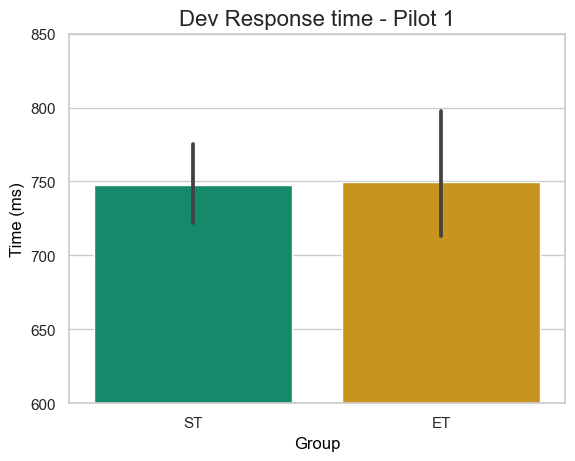

In [ ]:
import plotly.express as px

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Dev_cleaned, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(500, 750)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Dev Response time - Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# Save the figure
plt.savefig("response_time_dev.png")

# Show the plot
plt.show()

# plt.savefig("response_time_buttons.png")

#### RT NonDev

In [ ]:
BandR_NonDev = BandR_NonDev.reset_index()
# BandR_NonDev['index'] = BandR_NonDev['index'] - 1

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = BandR_NonDev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_NonDev = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_NonDev)

Group   
ST     2    526.202247
Name: Response time, dtype: float64


In [ ]:
outliers_RT_NonDev = pd.DataFrame(outliers_RT_NonDev).reset_index()
outliers_RT_NonDev_subIds = outliers_RT_NonDev['level_1']


In [ ]:
df_RT_NonDev_cleaned = BandR_NonDev[~BandR_NonDev['index'].isin(outliers_RT_NonDev_subIds)]

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ST']['Response time'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ET']['Response time']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9722180962562561, pvalue=0.8197944760322571)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9710051417350769, pvalue=0.7963759303092957)


In [ ]:
# Compare ET vs. ST 
data_st = df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ST']['Response time']
data_et = df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ET']['Response time']
n1_last, n2_last = len(data_et), len(data_st)

stat_last, p_last = mannwhitneyu(data_et, data_st)
r_last, z_last = compute_effect_size(stat_last, n1_last, n2_last)

# Print results
print(f"Mann-Whitney U test for 'last' between ET and ST: U = {stat_last}, p-value = {p_last}, Z = {z_last:.3f}, effect size r = {r_last:.3f}")



Mann-Whitney U test for 'last' between ET and ST: U = 186.0, p-value = 0.883942122067261, Z = 0.161, effect size r = 0.026


In [ ]:
df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ET'].describe()

,level_0,index,Response time
count,19.000000,19.000000,19.000000
mean,29.894737,9.894737,727.185071
std,5.801290,5.801290,49.036610
min,20.000000,0.000000,625.420455
25%,25.500000,5.500000,694.027910
50%,30.000000,10.000000,724.882353
75%,34.500000,14.500000,768.513501
max,39.000000,19.000000,805.074074


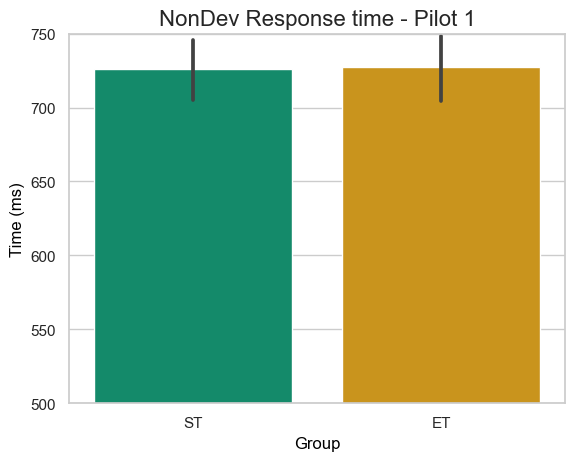

In [ ]:
import plotly.express as px

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_NonDev_cleaned, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(500, 750)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('NonDev Response time - Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_NonDev.png")

# Show the plot
plt.show()

# plt.savefig("response_time_buttons.png")

#### RT ET-Dev

In [ ]:
BandRET_Dev = BandRET_Dev.set_index('index').rename(columns={0:'Dev'}).drop(columns=['Group'])
BandRET_NonDev = BandRET_NonDev.set_index('index').rename(columns={0:'nonDev'})
ET_Dev = pd.concat([BandRET_NonDev, BandRET_Dev], axis=1)
# ET_Dev = ET_Dev.drop(columns=['Group'])

In [ ]:
ET_Dev = ET_Dev.reset_index().drop(columns=['index']).dropna()

In [ ]:
ET_Dev

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = ET_Dev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('level_0')['nonDev'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_ETDev = df.groupby('level_0')['nonDev'].apply(find_outliers)

# Print outliers
print(outliers_RT_ETDev)

Series([], Name: nonDev, dtype: float64)


In [ ]:
outliers_RT_ETDev = pd.DataFrame(outliers_RT_ETDev).reset_index()
outliers_RT_ETDev_subIds = outliers_RT_ETDev['level_1']


In [ ]:
df_RT_ETDev_cleaned = ET_Dev[~ET_Dev['index'].isin(outliers_RT_ETDev_subIds)]

In [ ]:
df_RT_ETDev_cleaned = df_RT_ETDev_cleaned.dropna()
df_RT_ETDev_cleaned

,index,nonDev,Group,Dev
0,0,693.362637,ET,675.000000
1,1,801.090909,ET,810.000000
2,3,768.505263,ET,955.000000
3,6,768.521739,ET,754.736842
4,8,742.529412,ET,737.108434
5,10,661.737374,ET,675.595238
6,11,690.300000,ET,710.687500
7,12,775.689189,ET,702.242105
8,13,665.734940,ET,704.135802
9,14,769.377778,ET,762.261364


In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_ETDev_cleaned['Dev'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_ETDev_cleaned['nonDev']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.8103104829788208, pvalue=0.012301558628678322)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9276567101478577, pvalue=0.35593539476394653)


In [ ]:

# Wilcoxon test for ET group
stat_ET, p_ET = wilcoxon(df_RT_ETDev_cleaned['Dev'], df_RT_ETDev_cleaned['nonDev'])

# Compute the z-score manually
N1 = len(df_RT_ETDev_cleaned['Dev'])  # Number of paired observations
z1 = (p_ET - (N1 * (N1 + 1) / 4)) / np.sqrt(N1 * (N1 + 1) * (2 * N1 + 1) / 24)

# Compute effect size (r)
r1 = z1 / np.sqrt(N1)

print(f"Wilcoxon test for ET: Statistic = {stat_ET}, p-value = {p_ET}, Z score = {z1:.3f}, Effect Size (r) = {r1:.3f}")


Wilcoxon test for ET: Statistic = 24.0, p-value = 0.26611328125, Z score = -3.039, Effect Size (r) = -0.877


In [ ]:
df_RT_ETDev_cleaned.describe()

,index,nonDev,Dev
count,12.000000,12.000000,12.000000
mean,9.083333,730.247593,749.672493
std,5.484828,46.837850,75.927172
min,0.000000,661.737374,675.000000
25%,5.250000,692.596978,703.662378
50%,10.500000,729.878836,739.580533
75%,13.250000,768.735749,763.508523
max,16.000000,801.090909,955.000000


In [ ]:
df_RT_ETDev_cleaned = df_RT_ETDev_cleaned.set_index('index')
df_RT_ETDev_cleaned = df_RT_ETDev_cleaned.melt()
df_RT_ETDev_cleaned

,variable,value
0,nonDev,693.362637
1,nonDev,801.090909
2,nonDev,768.505263
3,nonDev,768.521739
4,nonDev,742.529412
5,nonDev,661.737374
6,nonDev,690.3
7,nonDev,775.689189
8,nonDev,665.73494
9,nonDev,769.377778


In [ ]:
# import plotly.express as px

# # Define custom colors
# custom_palette = {"Dev": "#E69F00", "nonDev": "#009E73"}

# # Create the bar plot with custom colors
# ax = sns.barplot(data=df_RT_ETDev_cleaned, x=df_RT_ETDev_cleaned["variable"], y=df_RT_ETDev_cleaned["value"], palette=custom_palette)

# # Set axis limits
# plt.ylim(500, 750)

# # Customize axis labels
# ax.set_xlabel("SubGroup", fontdict={'fontsize': 12, 'color': 'black'})
# ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

# plt.title('Dev Response time - ET group, Pilot 1', fontsize=16)
# # plt.xlabel('Group', fontsize=12)
# # plt.ylabel('Correct Presses Percentage', fontsize=12)
# # Save the figure
# plt.savefig("response_time_dev_ET.png")

# # Show the plot
# plt.show()

# # plt.savefig("response_time_buttons.png")

#### RT ST-Dev

In [ ]:
BandRST_Dev = BandRST_Dev.set_index('index').rename(columns={0:'Dev'}).drop(columns=['Group'])
BandRST_NonDev = BandRST_NonDev.set_index('index').rename(columns={0:'nonDev'})
ST_Dev = pd.concat([BandRST_NonDev, BandRST_Dev], axis=1)
# ST_Dev = ST_Dev.drop(columns=['Group'])

In [ ]:
ST_Dev = ST_Dev.reset_index()

In [ ]:
ST_Dev = ST_Dev.dropna().drop(columns=['index'])
ST_Dev

,nonDev,Group,Dev
0,794.967033,ST,870.000000
1,749.846154,ST,795.338983
2,526.202247,ST,645.760000
3,671.231707,ST,796.853333
4,737.032258,ST,733.440476
5,640.200000,ST,671.675000
6,765.877778,ST,754.529412
7,689.280000,ST,707.782051
8,683.305263,ST,746.037037
9,717.652632,ST,742.632353


In [ ]:
# ST_Dev = ST_Dev.drop(columns=['level_0','index'])
Dev_all_RT3 = pd.concat([ST_Dev,ET_Dev]).drop(columns=['level_0'])
Dev_all_RT3["Pilot"] = 3

In [ ]:
Dev_all_RT3.to_csv('Dev_all_RT3.csv')

In [ ]:
Dev_all_RT3

,nonDev,Group,Dev,Pilot
0,794.967033,ST,870.000000,3
1,749.846154,ST,795.338983,3
2,526.202247,ST,645.760000,3
3,671.231707,ST,796.853333,3
4,737.032258,ST,733.440476,3
5,640.200000,ST,671.675000,3
6,765.877778,ST,754.529412,3
7,689.280000,ST,707.782051,3
8,683.305263,ST,746.037037,3
9,717.652632,ST,742.632353,3


In [ ]:
# Assuming your DataFrame is stored as 'df'
df = ST_Dev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('index')['nonDev'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_STDev = df.groupby('index')['nonDev'].apply(find_outliers)

# Print outliers
print(outliers_RT_STDev)

Series([], Name: nonDev, dtype: float64)


In [ ]:
outliers_RT_STDev = pd.DataFrame(outliers_RT_STDev).reset_index()
outliers_RT_STDev_subIds = outliers_RT_STDev['level_1']


In [ ]:
df_RT_STDev_cleaned = ST_Dev[~ST_Dev['index'].isin(outliers_RT_STDev_subIds)]

In [ ]:
df_RT_STDev_cleaned.dropna()

,index,nonDev,Group,Dev
0,0,794.967033,ST,870.000000
1,1,749.846154,ST,795.338983
2,2,526.202247,ST,645.760000
3,3,671.231707,ST,796.853333
4,4,737.032258,ST,733.440476
5,5,640.200000,ST,671.675000
6,6,765.877778,ST,754.529412
7,7,689.280000,ST,707.782051
8,8,683.305263,ST,746.037037
9,9,717.652632,ST,742.632353


In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_STDev_cleaned['Dev'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_STDev_cleaned['nonDev']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9836824536323547, pvalue=0.9831567406654358)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8947716355323792, pvalue=0.05557269603013992)


In [ ]:

# Wilcoxon test for ET group
stat_ST, p_ST = wilcoxon(df_RT_STDev_cleaned['Dev'], df_RT_STDev_cleaned['nonDev'])

# Compute the z-score manually
N1 = len(df_RT_STDev_cleaned['Dev'])  # Number of paired observations
z1 = (p_ET - (N1 * (N1 + 1) / 4)) / np.sqrt(N1 * (N1 + 1) * (2 * N1 + 1) / 24)

# Compute effect size (r)
r1 = z1 / np.sqrt(N1)

print(f"Wilcoxon test for ET: Statistic = {stat_ST}, p-value = {p_ST}, Z score = {z1:.3f}, Effect Size (r) = {r1:.3f}")


Wilcoxon test for ET: Statistic = 19.0, p-value = 0.004638671875, Z score = -3.609, Effect Size (r) = -0.875


In [ ]:
df_RT_STDev_cleaned.describe()

,index,nonDev,Dev
count,17.000000,17.000000,17.000000
mean,8.000000,711.789224,747.717702
std,5.049752,65.421994,57.381364
min,0.000000,526.202247,645.760000
25%,4.000000,683.305263,705.901235
50%,8.000000,717.652632,746.037037
75%,12.000000,765.877778,795.338983
max,16.000000,794.967033,870.000000


In [ ]:
df_RT_STDev_cleaned = df_RT_STDev_cleaned.set_index('index')
df_RT_STDev_cleaned = df_RT_STDev_cleaned.melt()
# df_RT_STDev_cleaned

In [ ]:
import plotly.express as px

# Define custom colors
custom_palette = {"Dev": "maroon", "nonDev": "turquoise"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_STDev_cleaned, x=df_RT_STDev_cleaned['variable'], y=df_RT_STDev_cleaned['value'], palette=custom_palette)

# Set axis limits
plt.ylim(500, 800)

# Customize axis labels
ax.set_xlabel("SubGroup", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Response time ST group - Devaluation (Pilot 3)', fontsize=16)
plt.xlabel('Buttons', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_dev_ST.png")

# Show the plot
plt.show()

# plt.savefig("response_time_buttons.png")

TypeError: Neither the `x` nor `y` variable appears to be numeric.

## Presses over time

In [ ]:
find_dev_pressesBlue11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:11]]).correctFirstBluePressDevtest.dropna().reset_index()
find_dev_pressesBlue11 = find_dev_pressesBlue11[find_dev_pressesBlue11['correctFirstBluePressDevtest'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_dev_pressesBlue11 = find_dev_pressesBlue11.rename(columns={'correctFirstBluePressDevtest': 'NondevPresses'})
find_dev_pressesBlue11['Group'] = 'ST'

find_dev_pressesRed11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:11]]).correctFirstRedPressDevtest.dropna().reset_index()
find_dev_pressesRed11 = find_dev_pressesRed11[find_dev_pressesRed11['correctFirstRedPressDevtest'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_dev_pressesRed11 = find_dev_pressesRed11.rename(columns={'correctFirstRedPressDevtest': 'DevPresses'})
find_dev_pressesBlue11['Group'] = 'ST'

find_dev_pressesBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:12]]).correctFirstBluePressDevtest.dropna().reset_index()
find_dev_pressesBlue12 = find_dev_pressesBlue12[find_dev_pressesBlue12['correctFirstBluePressDevtest'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_dev_pressesBlue12 = find_dev_pressesBlue12.rename(columns={'correctFirstBluePressDevtest': 'DevPresses'})

find_dev_pressesRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:12]]).correctFirstRedPressDevtest.dropna().reset_index()
find_dev_pressesRed12 = find_dev_pressesRed12[find_dev_pressesRed12['correctFirstRedPressDevtest'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_dev_pressesRed12 = find_dev_pressesRed12.rename(columns={'correctFirstRedPressDevtest': 'NondevPresses'})

find_dev_pressesBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:13]]).correctFirstBluePressDevtest.dropna().reset_index()
find_dev_pressesBlue13 = find_dev_pressesBlue13[find_dev_pressesBlue13['correctFirstBluePressDevtest'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_dev_pressesBlue13 = find_dev_pressesBlue13.rename(columns={'correctFirstBluePressDevtest': 'NondevPresses'})

find_dev_pressesRed13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:13]]).correctFirstRedPressDevtest.dropna().reset_index()
find_dev_pressesRed13 = find_dev_pressesRed13[find_dev_pressesRed13['correctFirstRedPressDevtest'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_dev_pressesRed13 = find_dev_pressesRed13.rename(columns={'correctFirstRedPressDevtest': 'DevPresses'})

find_dev_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:14]]).correctFirstBluePressDevtest.dropna().reset_index()
find_dev_pressesBlue14 = find_dev_pressesBlue14[find_dev_pressesBlue14['correctFirstBluePressDevtest'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_dev_pressesBlue14 = find_dev_pressesBlue14.rename(columns={'correctFirstBluePressDevtest': 'DevPresses'})

find_dev_pressesRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:14]]).correctFirstRedPressDevtest.dropna().reset_index()
find_dev_pressesRed14 = find_dev_pressesRed14[find_dev_pressesRed14['correctFirstRedPressDevtest'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_dev_pressesRed14 = find_dev_pressesRed14.rename(columns={'correctFirstRedPressDevtest': 'NondevPresses'})


In [ ]:
devPressesTimesST = pd.concat([find_dev_pressesRed11,find_dev_pressesBlue12]).set_index("subId")
devPressesTimesST['Group'] = 'ST'
devPressesTimesET = pd.concat([find_dev_pressesRed13,find_dev_pressesBlue14]).set_index("subId")
devPressesTimesET['Group'] = 'ET'
devPressesTimes = pd.concat([devPressesTimesST,devPressesTimesET])
devPressesTimes = devPressesTimes.drop(columns=['createdAt'])
nondevPressesTimesST = pd.concat([find_dev_pressesBlue11,find_dev_pressesRed12]).set_index("subId")
nondevPressesTimesST['Group'] = 'ST'
nondevPressesTimesET = pd.concat([find_dev_pressesBlue13,find_dev_pressesRed14]).set_index("subId")
nondevPressesTimesET['Group'] = 'ET'
nondevPressesTimes = pd.concat([nondevPressesTimesST,nondevPressesTimesET])
#allPressTimes = pd.concat([devPressesTimes,nondevPressesTimes],axis=1)

In [ ]:
# allPressTimes = pd.concat([devPressesTimes,nondevPressesTimes],axis=1)
# allPressTimes = allPressTimes.drop(columns=['createdAt'])

In [ ]:
devPressesTimes.to_csv('devPressesTimes.csv')

## Check time play variability

In [ ]:
for i in range(11, 15):
    timeDf[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i]['subId'].isin(relevent_subIds[i])].createdAt.str[:10]])\
    ['expDaysDate'].sort_values().dropna().groupby(level=[0,1]).last().str[11:16].apply(pd.Timestamp)

In [ ]:
px.line(timeDf[14].unstack().T, markers=True)

In [ ]:
px.histogram(timeDf[13].unstack().T, barmode='overlay', nbins=50)

In [ ]:
timeDf[14].unstack().T.apply(lambda col: pd.Series({'Mean': col.mean(), 'Std': col.std(), 'Median': col.median()}))

In [ ]:
STD_df_13 = pd.DataFrame(timeDf[13].unstack().T.apply(lambda col: pd.Series({'Mean': col.mean(), 'Std': col.std(), 'Median': col.median()})).T['Std'])
STD_df_14 = pd.DataFrame(timeDf[14].unstack().T.apply(lambda col: pd.Series({'Mean': col.mean(), 'Std': col.std(), 'Median': col.median()})).T['Std'])

In [ ]:
STD_df = pd.concat([STD_df_13,STD_df_14])

In [ ]:
et_per = et_per.set_index('subId')

In [ ]:
STD_df['duration'] = pd.to_timedelta(STD_df['Std'])
STD_df['duration_seconds'] = STD_df['duration'].dt.total_seconds()/60/60
STD_df_13['duration'] = pd.to_timedelta(STD_df['Std'])
STD_df_13['duration_seconds'] = STD_df_13['duration'].dt.total_seconds()/60/60
STD_df_14['duration'] = pd.to_timedelta(STD_df['Std'])
STD_df_14['duration_seconds'] = STD_df_14['duration'].dt.total_seconds()/60/60

In [ ]:
STD_df['duration_seconds'].describe()

In [ ]:
import scipy.stats

pearson_corr, p_value = scipy.stats.pearsonr(STD_df['duration_seconds'], et_per[0])

print("Pearson correlation coefficient:", pearson_corr)
print("p-value:", p_value)


In [ ]:
pearson_corr, p_value = scipy.stats.pearsonr(STD_df_13['duration_seconds'], dev_lastANDtest[dev_lastANDtest['SubGroup']=='ET_Left']['dev'])

print("Pearson correlation coefficient:", pearson_corr)
print("p-value:", p_value)

In [ ]:
pearson_corr, p_value = scipy.stats.pearsonr(STD_df_14['duration_seconds'], dev_lastANDtest[dev_lastANDtest['SubGroup']=='ET_Right']['dev'])

print("Pearson correlation coefficient:", pearson_corr)
print("p-value:", p_value)

In [ ]:
import matplotlib.pyplot as plt

# Assuming df['duration_seconds'] contains the durations in seconds and et_per14 is another array
x = STD_df_14['duration_seconds']
y = dev_lastANDtest[dev_lastANDtest['SubGroup']=='ET_Right']['dev']

# Plotting
plt.figure(figsize=(8, 6))
#plt.scatter(x, y, alpha=0.5)
sns.regplot(x = x,y = y)
plt.title('Play time vs. Devaluation')
plt.xlabel('STD (Hours)')
plt.ylabel('Dev percent')
plt.grid(True)
plt.show()


In [ ]:
dev_lastANDtest = dev_lastANDtest.set_index('subId')

In [ ]:
# STD_df_13 = STD_df_13.reset_index()
# STD_df_14 = STD_df_14.reset_index()
# ET_Left = ET_Left.set_index('subId')
# ET_Right = ET_Right.set_index('subId')

## save as csv:
ET_left_Time = pd.concat([STD_df_13['duration_seconds'], dev_lastANDtest[dev_lastANDtest['SubGroup'] == 'ET_Left']['dev_percent']], axis=1)
ET_left_Time['Group'] = 'Left'
ET_right_Time = pd.concat([STD_df_14['duration_seconds'], dev_lastANDtest[dev_lastANDtest['SubGroup'] == 'ET_Right']['dev_percent']], axis=1)
ET_right_Time['Group'] = 'Right'

ET_time3 = pd.concat([ET_left_Time, ET_right_Time])
ET_time3['Pilot'] = 3
ET_time3.to_csv('ET_time3.csv')

In [ ]:
 ET_time3

## Response Onset Time 

#### ET group

In [ ]:
custom_palette = {"ET_Left": "red", "ET_Right": "blue"}
tmp_dct = {'subID': [], 'RT': [], 'Group': []}
i = 1

# Loop for ET_Left (Red)
for lst in dfs[13]['correctFirstRedPressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ET_Left' for _ in range(len(lst))]
        i += 1

# Loop for ET_Right (Blue)
for lst in dfs[14]['correctFirstBluePressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ET_Right' for _ in range(len(lst))]
        i += 1

# Create DataFrame
tmp_df = pd.DataFrame(tmp_dct)

# Plot using KDE plot
# sns.kdeplot(tmp_df, x='RT', hue='Group', palette=custom_palette)



In [ ]:
tmp_df_ET = tmp_df

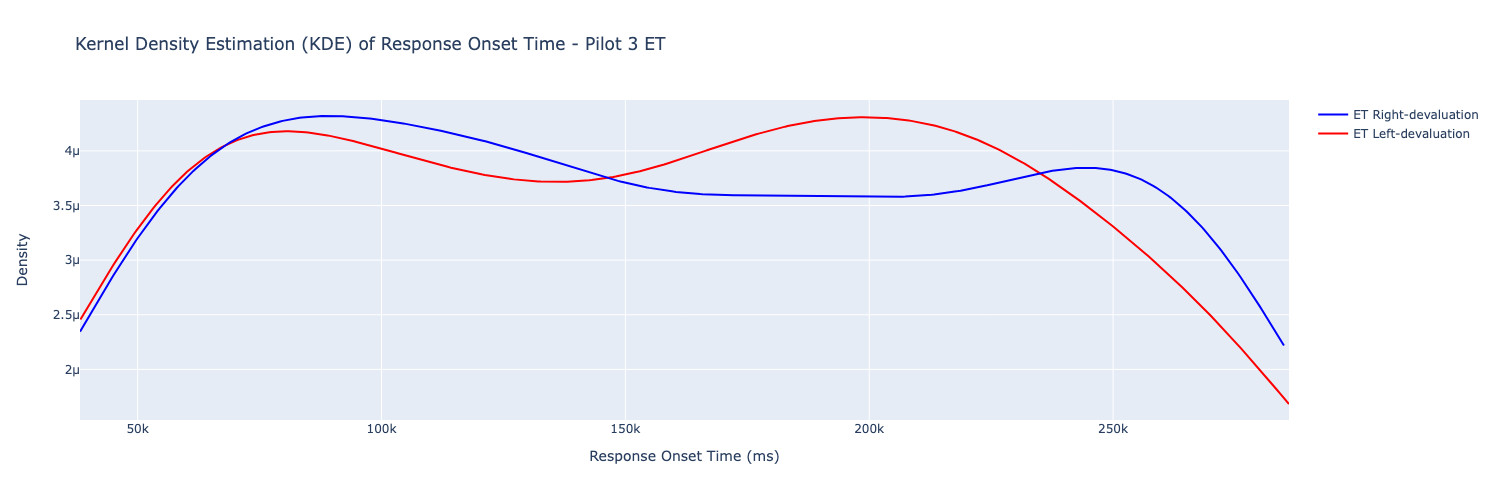

In [ ]:
import plotly.figure_factory as ff

group_left = tmp_df_ET[tmp_df_ET["Group"] == "ET_Left"]["RT"]
group_right = tmp_df_ET[tmp_df_ET["Group"] == "ET_Right"]["RT"]

# Group data together
hist_data = [group_left, group_right]
group_labels = ['ET Left-devaluation', 'ET Right-devaluation']

# Custom colors: ET_Left (Red), ET_Right (Blue)
colors = ['red', 'blue']

# Create distplot with KDE only and custom colors
fig = ff.create_distplot(hist_data, group_labels, bin_size=100, show_hist=False, show_rug=False, colors=colors)

# Add title and adjust layout
fig.update_layout(
    title="Kernel Density Estimation (KDE) of Response Onset Time - Pilot 3 ET",
    xaxis_title="Response Onset Time (ms)",
    yaxis_title="Density",
    width=800,
    height=500
)
fig.write_image("KDE_ROT_ET.png")

fig.show()


In [ ]:
tmp_df_ET[tmp_df_ET["Group"] == "ET_Right"]["RT"].describe()

count       405.000000
mean     158525.824691
std       74345.682477
min       38178.000000
25%       93788.000000
50%      153201.000000
75%      226311.000000
max      285526.000000
Name: RT, dtype: float64

In [ ]:
from scipy.stats import ks_2samp

# Example: Compare distributions of two groups
group_left = tmp_df_ET[tmp_df_ET["Group"] == "ET_Left"]["RT"]
group_right = tmp_df_ET[tmp_df_ET["Group"] == "ET_Right"]["RT"]


# Perform KS Test
ks_stat, p_value = ks_2samp(group_left, group_right)

# Print results
print(f"KS Statistic = {ks_stat:.4f}, p-value = {p_value:.6f}")

# Interpretation
if p_value < 0.05:
    print("Significant difference in distributions (reject null hypothesis)")
else:
    print("No significant difference in distributions (fail to reject null)")




KS Statistic = 0.0654, p-value = 0.472867
No significant difference in distributions (fail to reject null)


In [ ]:
tmp_df[tmp_df['Group'] == 'ET_Left']['RT'].describe()

count       266.000000
mean     156348.936090
std       72190.856648
min       38271.000000
25%       92085.000000
50%      158275.500000
75%      217217.250000
max      286569.000000
Name: RT, dtype: float64

In [ ]:
tmp_df[tmp_df['Group'] == 'ET_Right']['RT'].describe()

count       405.000000
mean     158525.824691
std       74345.682477
min       38178.000000
25%       93788.000000
50%      153201.000000
75%      226311.000000
max      285526.000000
Name: RT, dtype: float64

#### ST group

In [ ]:
custom_palette = {"ST_Left": "red", "ST_Right": "blue"}
tmp_dct = {'subID': [], 'RT': [], 'Group': []}
i = 1

# Loop for ET_Left (Red)
for lst in dfs[11]['correctFirstRedPressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ST_Left' for _ in range(len(lst))]
        i += 1

# Loop for ET_Right (Blue)
for lst in dfs[12]['correctFirstBluePressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ST_Right' for _ in range(len(lst))]
        i += 1

# Create DataFrame
tmp_df_ST = pd.DataFrame(tmp_dct)
tmp_df_ST.to_csv('ST_data.csv')
# Plot using KDE plot
# sns.kdeplot(tmp_df, x='RT', hue='Group', palette=custom_palette)


In [ ]:
tmp_df_ST[tmp_df_ST['Group'] == 'ST_Left']['RT'].describe()

count       568.000000
mean     164447.130282
std       72894.727022
min       38230.000000
25%      101063.250000
50%      169771.000000
75%      224418.500000
max      286045.000000
Name: RT, dtype: float64

In [ ]:
tmp_df_ST[tmp_df_ST['Group'] == 'ST_Right']['RT'].describe()

count       597.000000
mean     161271.479062
std       70293.938778
min       38301.000000
25%      102429.000000
50%      161551.000000
75%      221616.000000
max      285657.000000
Name: RT, dtype: float64

In [ ]:
from scipy.stats import ks_2samp

# Example: Compare distributions of two groups
group_left = tmp_df_ST[tmp_df_ST["Group"] == "ST_Left"]["RT"]
group_right = tmp_df_ST[tmp_df_ST["Group"] == "ST_Right"]["RT"]

# Perform KS Test
ks_stat, p_value = ks_2samp(group_left, group_right)

# Print results
print(f"KS Statistic = {ks_stat:.4f}, p-value = {p_value:.6f}")

# Interpretation
if p_value < 0.05:
    print("Significant difference in distributions (reject null hypothesis)")
else:
    print("No significant difference in distributions (fail to reject null)")



KS Statistic = 0.0568, p-value = 0.289193
No significant difference in distributions (fail to reject null)


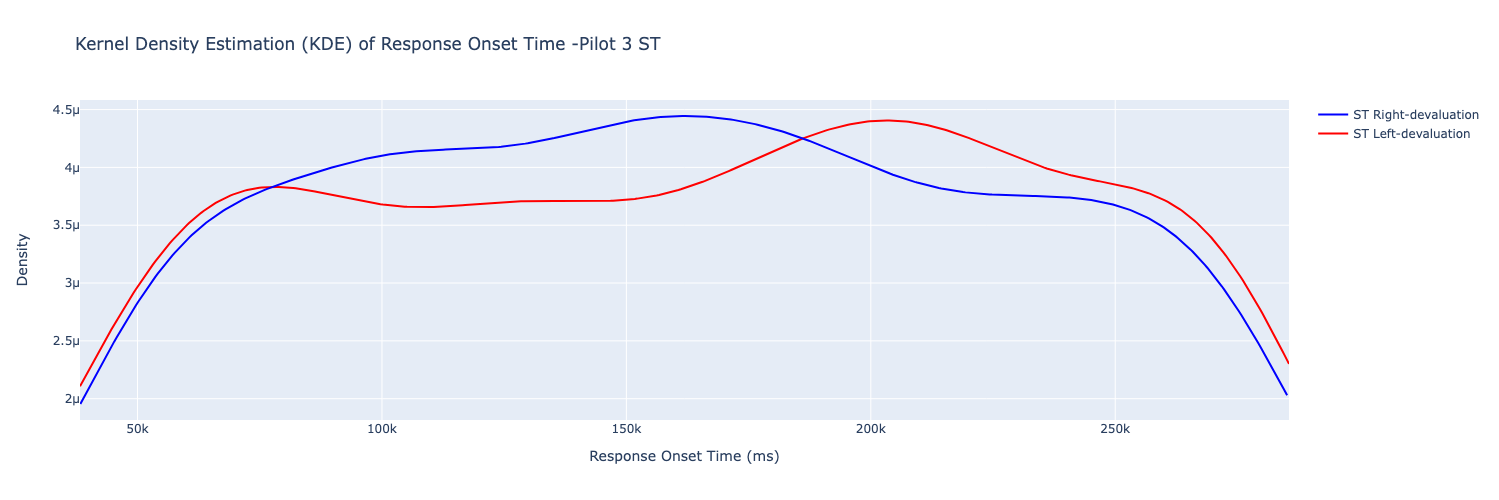

In [ ]:
import plotly.figure_factory as ff

group_left = tmp_df_ST[tmp_df_ST["Group"] == "ST_Left"]["RT"]
group_right = tmp_df_ST[tmp_df_ST["Group"] == "ST_Right"]["RT"]

# Group data together
hist_data = [group_left, group_right]
group_labels = ['ST Left-devaluation', 'ST Right-devaluation']

# Custom colors: ET_Left (Red), ET_Right (Blue)
colors = ['red', 'blue']

# Create distplot with KDE only and custom colors
fig = ff.create_distplot(hist_data, group_labels, bin_size=100, show_hist=False, show_rug=False, colors=colors)

# Add title and adjust layout
fig.update_layout(
    title="Kernel Density Estimation (KDE) of Response Onset Time -Pilot 3 ST",
    xaxis_title="Response Onset Time (ms)",
    yaxis_title="Density",
    width=800,
    height=500
)
fig.write_image("KDE_ROT_ST.png")

fig.show()


## Gender extract

In [ ]:
gender = {}

In [ ]:
info_table = pd.read_csv(r'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 3/subjects_info - sheet1.csv')
gender[11] = {
    'subId': info_table[(info_table.Experiment=='ST_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId,
    'gender': info_table[(info_table.Experiment=='ST_DevL2p')&(info_table['isExperimentDone?']==1)].Gender
    }
gender[12] = {
    'subId': info_table[(info_table.Experiment=='ST_DevR2p')&(info_table['isExperimentDone?']==1)].WorkerId,
    'gender': info_table[(info_table.Experiment=='ST_DevR2p')&(info_table['isExperimentDone?']==1)].Gender
    }
gender[13] = {
    'subId': info_table[(info_table.Experiment=='ET_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId,
    'gender': info_table[(info_table.Experiment=='ET_DevL2p')&(info_table['isExperimentDone?']==1)].Gender
    }
gender[14] = {
    'subId': info_table[(info_table.Experiment=='ET_DevR2p')&(info_table['isExperimentDone?']==1)].WorkerId,
    'gender': info_table[(info_table.Experiment=='ET_DevR2p')&(info_table['isExperimentDone?']==1)].Gender
    }

In [ ]:
for i in range (11,15):
    gender[i] = pd.DataFrame(gender[i])

In [ ]:
st_gender = pd.concat([gender[11],gender[12]]).set_index('subId')
et_gender = pd.concat([gender[13],gender[14]]).set_index('subId')


In [ ]:
genderAll = pd.concat([et_gender,st_gender])
genderAll.to_csv('gender3.csv')
genderAndDev = pd.concat([dev_lastANDtest,genderAll], axis=1)

In [ ]:
genderAndDev = genderAndDev.dropna()
genderAndDev.to_csv('genderAndDev3.csv')

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(genderAndDev[genderAndDev['Group']=='ST']['dev'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(genderAndDev[genderAndDev['Group']=='ET']['dev']))

In [ ]:
for group in genderAndDev['Group'].unique():
    subset = genderAndDev[genderAndDev['Group'] == group]
    stat, p = mannwhitneyu(subset[subset['gender'] == 0]['dev'], subset[subset['gender'] == 1]['dev'])
    print(f"Mann-Whitney for {group}: U = {stat}, p = {p:.6f}")
